In [ ]:
import numpy as np
from scipy.spatial import Delaunay
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

# ============================================================
# 1. 多场景目标函数建模
#    我们现在允许有 S 个场景。每个场景 s 给出它自己的参数。
#    全局真实目标 = sum_s p_s * f_s(x,y)
# ============================================================

# ----------【NEW】单个场景是一口高斯坑+轻微二次抬升----------
# f_s(x,y) = - depth * exp(- ||(x,y)-center||^2 / width^2 ) + bias_strength * ||(x,y)-bias_center||^2 + offset
def eval_single_gaussian(x, y, scen):
    cx, cy   = scen["center"]
    depth    = scen["depth"]
    width    = scen["width"]
    bs       = scen["outer_bias_strength"]
    bcx, bcy = scen["outer_bias_center"]
    offset   = scen["offset"]

    well_term = - depth * np.exp(-(((x-cx)**2 + (y-cy)**2)/(width**2)))
    bias_term = bs * ((x-bcx)**2 + (y-bcy)**2)
    return well_term + bias_term + offset

# ----------【NEW】多场景集合----------
# SCENARIOS = [
#     { "p":0.5, "center":[...], "depth":..., "width":..., "outer_bias_strength":..., "outer_bias_center":[...], "offset":... },
#     { "p":0.5, ... },
#     ...
# ]
SCENARIOS = []  # 会在 main 里用random_scenarios()填充

# ----------【NEW】计算期望真实函数 f_true_numpy(xy) = sum p_s f_s(xy)----------
def f_true_numpy(xy):
    x = float(xy[0])
    y = float(xy[1])
    total = 0.0
    for scen in SCENARIOS:
        ps = scen["p"]
        total += ps * eval_single_gaussian(x, y, scen)
    return total

# ----------【NEW】返回 Pyomo 表达式版期望函数 ----------
def f_true_expr(m):
    expr = 0
    for scen in SCENARIOS:
        ps = float(scen["p"])
        cx, cy   = float(scen["center"][0]), float(scen["center"][1])
        depth    = float(scen["depth"])
        width    = float(scen["width"])
        bs       = float(scen["outer_bias_strength"])
        bcx, bcy = float(scen["outer_bias_center"][0]), float(scen["outer_bias_center"][1])
        offset   = float(scen["offset"])

        term_well = -depth * pyo.exp(-(((m.x - cx)**2 + (m.y - cy)**2)/(width**2)))
        term_bias = bs * ((m.x - bcx)**2 + (m.y - bcy)**2)
        expr += ps * (term_well + term_bias + offset)
    return expr


# ============================================================
# 2. 构建/复用Pyomo模型 (同一结构每次复用并清理)
# ============================================================
def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m

def drop_simplex_stuff(m):
    for nm in ['lam','lam_sum','x_link_x','x_link_y','As','As_con','obj']:
        if hasattr(m, nm):
            m.del_component(nm)

# ============================================================
# 3. 在每个三角形里解 ms
#    注意这里的 f_true_* 已经是期望了
# ============================================================
def minimize_on_each_triangle(nodes, values, solver='ipopt', tee=False):
    """
    nodes: list of R^2 points
    values: list of f_true_numpy(node)  (期望值!)
    返回:
      tri: Delaunay
      results: list of dict per simplex with ms, LB, UB 等
    """
    pts  = np.asarray(nodes, dtype=float)   # (N,2)
    vals = np.asarray(values, dtype=float)  # (N,)
    tri = Delaunay(pts)                     # tri.simplices: (K,3)

    m = build_model()
    opt = pyo.SolverFactory(solver)
    if solver == "gurobi":
        opt.options["NonConvex"] = 2

    results = []
    for k, simp in enumerate(tri.simplices):
        verts   = pts[simp]     # (3,2)
        fverts  = vals[simp]    # (3,)

        # 重心变量 lam_j >=0, sum lam =1
        m.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
        m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(3)) == 1.0)

        # x = sum lam_j * v_jx,  y = sum lam_j * v_jy
        m.x_link_x = pyo.Constraint(expr=m.x == sum(m.lam[j]*float(verts[j,0]) for j in range(3)))
        m.x_link_y = pyo.Constraint(expr=m.y == sum(m.lam[j]*float(verts[j,1]) for j in range(3)))

        # As = sum lam_j * f(v_j)  [线性插值的代理值, 也是期望值的线性插值]
        m.As = pyo.Var()
        m.As_con = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(fverts[j]) for j in range(3)))

        # 目标：min (f_true_expr - As)
        m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)

        x_ms = np.array([pyo.value(m.x), pyo.value(m.y)], dtype=float)
        ms_val = float(pyo.value(m.obj))       # 这个三角形下的 ms
        f_at_x_ms = f_true_numpy(x_ms)         # 期望函数在最差点的真实值

        # LB = min As + ms = min f(v) + ms
        LB = float(np.min(fverts) + ms_val)

        # UB = min( min f(v), f(x_ms) )
        UB = float(min(np.min(fverts), f_at_x_ms))

        results.append({
            "simplex_index": int(k),
            "vertices_index": simp.tolist(),
            "verts": verts,
            "fverts": fverts,
            "x_ms": x_ms,
            "ms": ms_val,
            "LB": LB,
            "UB": UB,
            "f(x_ms)": f_at_x_ms,
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

        drop_simplex_stuff(m)

    return tri, results


# ============================================================
# 4. 全局LB口径（保持你的逻辑）
#    v* = 当前节点里 f_true 最小的节点
#    LB_iter = f_true(v*) + max_{Δ包含v*} ms_Δ
# ============================================================
def compute_lb_min_node_max_ms(nodes, values, per_tri):
    idx_min = int(np.argmin(values))
    ms_candidates = [r['ms'] for r in per_tri if idx_min in r['vertices_index']]
    if ms_candidates:
        return float(values[idx_min] + max(ms_candidates)), idx_min, float(max(ms_candidates))
    fallback = float(min(r['LB'] for r in per_tri))
    return fallback, idx_min, float('nan')


# ============================================================
# 5. 选点策略&表格打印 （原样保留）
# ============================================================
def pick_candidate_by_ms_rank(per_tri, nodes, min_dist=1e-6, descending=False):
    """
    在 per_tri 中按 ms 排序（默认从小到大，因为 descending=False）
    逐个检查 x_ms 是否离已有节点足够远。
    """
    cands = sorted(per_tri, key=lambda r: r['ms'], reverse=descending)

    def ok(p):
        return all(np.linalg.norm(p - q) >= min_dist for q in nodes)

    for rank, r in enumerate(cands, start=1):
        p = np.array(r['x_ms'], float)
        if ok(p):
            return p, rank, float(r['ms'])
    return None, None, None


def print_per_triangle_table(results, active_mask):
    results = sorted(results, key=lambda r: r["simplex_index"])
    simplex_ids = [r["simplex_index"] for r in results]
    active_set = {sid for sid in simplex_ids if active_mask[sid]}

    header = ["row\\simp"] + [f"T{sid}{'*' if sid in active_set else ''}" for sid in simplex_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.6f}" for r in results],
        ["LB"] + [f"{r['LB']:.6f}" for r in results],
        ["ms"] + [f"{r['ms']:.3e}" for r in results],
    ]
    table = [header] + rows

    ncols = len(header)
    colw = [0]*ncols
    for c in range(ncols):
        colw[c] = max(len(str(row[c])) for row in table) + 2

    RED = "\033[31m"
    RESET = "\033[0m"

    def colorize_if_active(col_idx: int, s: str) -> str:
        if col_idx == 0:
            return s
        sid = simplex_ids[col_idx-1]
        return f"{RED}{s}{RESET}" if sid in active_set else s

    header_line = "".join(str(header[c]).ljust(colw[c]) if c == 0
                          else colorize_if_active(c, str(header[c]).ljust(colw[c]))
                          for c in range(ncols))
    print("\n== Per-triangle summary ==")
    print(header_line)
    print("-" * sum(colw))

    for r in rows:
        line = []
        for c in range(ncols):
            cell = str(r[c])
            padded = cell.ljust(colw[c]) if c == 0 else cell.rjust(colw[c])
            line.append(colorize_if_active(c, padded))
        print("".join(line))

    print("(红色列 = active；第1行=UB，第2行=LB，第3行=ms)\n")


# ============================================================
# 6. 每一轮的3D可视化
#    注意：这张图画的是真实期望函数曲面 (sum p_s f_s)
#    以及 active 单形的 As+ms “屋顶”
# ============================================================
def plot_iteration(iter_id, nodes, tri, active_mask,
                   grid_n=60, elev=35, azim=-135,
                   min_node=None, new_node=None,
                   per_tri=None):
    nodes = np.asarray(nodes, float)

    COLOR_SURFACE = 'C0'           # 真实期望函数曲面
    COLOR_NODE_EDGES = '#444444'   # active 单形的原函数折线
    COLOR_PIECE = '#ff7043'        # As+ms 屋顶
    LW_MAIN = 2.2

    xs = np.linspace(0, 10, grid_n)
    ys = np.linspace(0, 10, grid_n)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.zeros_like(XX)
    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            ZZ[i,j] = f_true_numpy([XX[i,j], YY[i,j]])  # 期望值

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    # 真实期望函数曲面
    ax.plot_surface(XX, YY, ZZ, alpha=0.35, linewidth=0,
                    antialiased=True, color=COLOR_SURFACE)

    # 画 active 分片的 As+ms 屋顶
    if per_tri is not None and len(per_tri) > 0 and tri is not None:
        faces = []
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]     # (3,2)
            fverts   = r["fverts"]    # (3,)
            ms_val   = r["ms"]
            tri_xyz  = [
                (verts_xy[i,0], verts_xy[i,1], float(fverts[i] + ms_val))
                for i in range(3)
            ]
            faces.append(tri_xyz)

        if faces:
            coll = Poly3DCollection(
                faces,
                facecolors=[COLOR_PIECE],
                edgecolors='none',
                alpha=0.55
            )
            ax.add_collection3d(coll)

        # active单形的屋顶边线
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]
            fverts   = r["fverts"]
            ms_val   = r["ms"]
            for i in range(3):
                a_xy = verts_xy[i]
                b_xy = verts_xy[(i+1) % 3]
                za = float(fverts[i] + ms_val)
                zb = float(fverts[(i+1) % 3] + ms_val)
                ax.plot([a_xy[0], b_xy[0]],
                        [a_xy[1], b_xy[1]],
                        [za, zb],
                        lw=LW_MAIN, c=COLOR_PIECE)

    # 所有节点 (黑点)
    node_z = np.array([f_true_numpy(p) for p in nodes])
    ax.scatter(nodes[:,0], nodes[:,1], node_z, s=30, c='k', depthshade=False)

    # active 单形在真实曲面上的边线 + 质心
    if tri is not None:
        for k, simp in enumerate(tri.simplices):
            if not active_mask.get(k, False):
                continue
            verts_xy = tri.points[simp]
            for i in range(3):
                a, b = verts_xy[i], verts_xy[(i+1) % 3]
                ax.plot([a[0], b[0]], [a[1], b[1]],
                        [f_true_numpy(a), f_true_numpy(b)],
                        lw=LW_MAIN, c=COLOR_NODE_EDGES)

            centroid = np.mean(verts_xy, axis=0)
            ax.scatter([centroid[0]], [centroid[1]],
                       [f_true_numpy(centroid)],
                       marker='^', c=COLOR_NODE_EDGES,
                       s=70, depthshade=False)

    # 当前最优节点
    if min_node is not None:
        ax.scatter([min_node[0]], [min_node[1]],
                   [f_true_numpy(min_node)],
                   color='g', s=80, marker='o', label='Current min node')

    # 下一轮要加的新节点
    if new_node is not None:
        ax.scatter([new_node[0]], [new_node[1]],
                   [f_true_numpy(new_node)],
                   color='b', s=80, marker='o', label='Next node')

    ax.set_title(f"Iteration {iter_id}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("E[f(x,y)]")
    ax.legend(loc='upper left')
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


# ============================================================
# 7. 全局收敛曲线 (基本不改)
# ============================================================
def plot_convergence(hist, prec=4):
    x  = hist["node_count"]
    LB = hist["LB_hist"]
    UB = hist["UB_hist"]
    ms = hist["ms_hist"]

    # LB/UB
    plt.figure(figsize=(6,4))
    plt.plot(x, LB, marker='o', label="LB (lower bound)")
    plt.plot(x, UB, marker='s', label="UB (upper bound)")
    plt.xlabel("Number of nodes")
    plt.ylabel("Bound value")
    plt.title("Global LB and UB vs Number of Nodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # ms
    plt.figure(figsize=(6,4))
    plt.plot(x, ms, marker='o', color='C2')
    plt.xlabel("Number of nodes")
    plt.ylabel("Global ms (min over active simplices)")
    plt.title("ms vs Number of Nodes (Simplex method)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 表格
    print("\n==== Summary Table ====")
    fmt = f"{{:.{prec}f}}"
    header = f"{'Nodes':>8s} | {'ms':>12s} | {'LB':>12s} | {'UB':>12s}"
    print(header)
    print("-" * len(header))
    for n, m, lb, ub in zip(x, ms, LB, UB):
        print(f"{n:8d} | {fmt.format(m):>12s} | {fmt.format(lb):>12s} | {fmt.format(ub):>12s}")
    print("-" * len(header))
    print(f"{'Total':>8s} | {len(x):>12d}")


# ============================================================
# 8. 主循环：基本同你原来的 run_case
#    区别：一切 values / f_true_numpy 都是“期望值”
# ============================================================
def run_case(max_nodes=10, solver='ipopt', tee=False, plot_grid_n=60,
             record_history=True, make_3d_plots=True,
             only_from_active=True, min_dist=1e-4, active_tol=1e-8,
             print_tables=True):
    """
    only_from_active: True 则仅在 active 单形里挑 next node
    """
    # 初始 4 角点
    nodes = [
        np.array([0.0,0.0]),
        np.array([0.0,10.0]),
        np.array([10.0,0.0]),
        np.array([10.0,10.0])
    ]
    values = [f_true_numpy(p) for p in nodes]  # 期望值

    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []

    it = 0
    while len(nodes) < max_nodes:
        tri, per_tri = minimize_on_each_triangle(nodes, values, solver=solver, tee=tee)

        # 本轮全局 UB = 当前所有节点的最小期望值
        UB_global = float(np.min(values))

        # LB_iter = f(min-node) + max_{Δ包含该点} ms_Δ
        LB_iter, idx_min_node, ms_chosen = compute_lb_min_node_max_ms(nodes, values, per_tri)

        # ms_iter = 所有单形的最小 ms
        ms_iter = min(r['ms'] for r in per_tri)

        if record_history:
            LB_hist.append(LB_iter)
            UB_hist.append(UB_global)
            ms_hist.append(ms_iter)
            node_count.append(len(nodes))

        # active 单形： LB <= UB_global + active_tol
        active_mask = { r['simplex_index']: (r['LB'] <= UB_global + active_tol) for r in per_tri }
        active_tris = [r for r in per_tri if r['LB'] <= UB_global + active_tol]

        candidates = active_tris if (only_from_active and len(active_tris) > 0) else per_tri
        if only_from_active and len(active_tris) == 0:
            print(f"[warn] No active simplices this round (tol={active_tol:g}); fall back to all simplices.")

        # 选新点（按 ms 小优先，且保持距离）
        new_node, used_rank, used_ms = pick_candidate_by_ms_rank(
            candidates, nodes, min_dist=min_dist, descending=False
        )
        if new_node is None:
            print("All candidates too close; stop.")
            break

        # 打印表格（本轮）
        if print_tables:
            print(f"\n===== Iteration {it} =====")
            print(f"UB_global = {UB_global:.6f}")
            print(f"LB_iter   = {LB_iter:.6f}")
            print(f"ms_iter   = {ms_iter:.6e}")
            print_per_triangle_table(per_tri, active_mask)

        # 画3D
        if make_3d_plots:
            plot_iteration(
                it, nodes, tri, active_mask,
                grid_n=plot_grid_n,
                min_node=nodes[idx_min_node],
                new_node=new_node,
                per_tri=per_tri
            )

        # 把新点加入
        if any(np.linalg.norm(new_node - q) < min_dist for q in nodes):
            print("New node too close to an existing node; stop.")
            break
        nodes.append(new_node)
        values.append(f_true_numpy(new_node))

        it += 1

    return {
        "nodes": np.array(nodes), "values": np.array(values),
        "LB_hist": LB_hist, "UB_hist": UB_hist, "ms_hist": ms_hist,
        "node_count": node_count
    }


# ============================================================
# 9. 随机生成场景 【NEW核心】
#    我们会随机 N 个高斯坑场景:
#    - 井中心随机在 [0,10]x[0,10]
#    - depth 正值 (越大=越深=越负)
#    - width 控制井范围
#    - outer_bias_strength 小正数，往中心(5,5)拉
#    - offset 统一可以0
#
#    返回一组字典，每个加上 p=1/N (均匀权重)
# ============================================================
def random_scenarios(num_scenarios,
                     domain_low=0.0, domain_high=10.0,
                     depth_range=(0.8, 2.0),
                     width_range=(0.8, 2.0),
                     bias_strength_range=(0.02, 0.08),
                     bias_center=(5.0,5.0),
                     offset=0.0,
                     seed=None):
    rng = np.random.default_rng(seed)
    scens = []
    for _ in range(num_scenarios):
        cx = rng.uniform(domain_low, domain_high)
        cy = rng.uniform(domain_low, domain_high)
        depth = rng.uniform(*depth_range)
        width = rng.uniform(*width_range)
        bs = rng.uniform(*bias_strength_range)
        scens.append({
            "center": np.array([cx, cy], dtype=float),
            "depth": float(depth),
            "width": float(width),
            "outer_bias_strength": float(bs),
            "outer_bias_center": np.array(bias_center, dtype=float),
            "offset": float(offset),
            # p 会先留空，下面再统一填
        })
    # 均匀概率
    pval = 1.0/len(scens)
    for s in scens:
        s["p"] = pval
    return scens


# ============================================================
# 10. main：生成场景 -> 跑算法 -> 画收敛
# ============================================================
if __name__ == "__main__":
    # 【NEW】随机生成多场景
    # 例如 3 个场景，平均权重
    SCENARIOS = random_scenarios(
        num_scenarios=3,
        seed=42  # 固定随机数种子方便复现
    )

    solver      = "ipopt"   # 也可以"gurobi"
    max_nodes   = 20
    plot_3d     = True
    record_hist = True

    hist_simp = run_case(
        max_nodes=max_nodes,
        solver=solver,
        tee=False,
        plot_grid_n=60,
        record_history=record_hist,
        make_3d_plots=plot_3d,
        only_from_active=True,
        min_dist=1e-4,
        active_tol=1e-8,
        print_tables=True
    )

    plot_convergence(hist_simp, prec=4)

    nodes  = hist_simp["nodes"]
    values = hist_simp["values"]
    print("\n==== Done ====")
    print(f"Total nodes: {len(nodes)}")
    print(f"Best expected f among nodes: {np.min(values):.6f}")


ValueError: Model objective (obj) contains nonlinear terms that cannot be written to LP format

In [ ]:
# ======== 真实函数（也是 obj_expr ）========
def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return 2.0*(x - 3.0)**2 + 3.0*(y - 5.0)**2

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m

def f_true_expr(m):
    return 2*(m.x - 3)**2 + 3*(m.y - 5)**2

In [4]:
# ======== 双高斯坑目标，替代原抛物面 ========

QUADWELL_PARAMS = {
    "well1": {
        "center": np.array([3.5, 4.0], dtype=float),
        "A": np.array([[1.2, 0.0],
                       [0.0, 0.6]], dtype=float),
        "depth": 1.0,   # 原来是 5.0，调低 -> 更平缓
    },
    "well2": {
        "center": np.array([6.5, 6.0], dtype=float),
        "A": np.array([[0.7, 0.0],
                       [0.0, 1.4]], dtype=float),
        "depth": 1.0001,
    },
    "outer_bias_strength": 0.05,
    "outer_bias_center": np.array([5.0, 5.0], dtype=float),
    "offset": 0.0,
}


def f_true_numpy(xy):
    x = float(xy[0])
    y = float(xy[1])

    p  = DOUBLEWELL_PARAMS
    c1 = p["well1"]["center"]; a1 = p["well1"]["depth"]; w1 = p["well1"]["width"]
    c2 = p["well2"]["center"]; a2 = p["well2"]["depth"]; w2 = p["well2"]["width"]

    term1 = -a1 * np.exp(-((x - c1[0])**2 + (y - c1[1])**2) / (w1**2))
    term2 = -a2 * np.exp(-((x - c2[0])**2 + (y - c2[1])**2) / (w2**2))

    bc = p["outer_bias_center"]; bs = p["outer_bias_strength"]
    bias = bs * ((x - bc[0])**2 + (y - bc[1])**2)

    return term1 + term2 + bias + p["offset"]

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m

def f_true_expr(m):
    p  = DOUBLEWELL_PARAMS

    c1x, c1y = float(p["well1"]["center"][0]), float(p["well1"]["center"][1])
    a1       = float(p["well1"]["depth"])
    w1       = float(p["well1"]["width"])

    c2x, c2y = float(p["well2"]["center"][0]), float(p["well2"]["center"][1])
    a2       = float(p["well2"]["depth"])
    w2       = float(p["well2"]["width"])

    bc_x, bc_y = float(p["outer_bias_center"][0]), float(p["outer_bias_center"][1])
    bs         = float(p["outer_bias_strength"])
    offset     = float(p["offset"])

    term1 = -a1 * pyo.exp(-(((m.x - c1x)**2 + (m.y - c1y)**2) / (w1**2)))
    term2 = -a2 * pyo.exp(-(((m.x - c2x)**2 + (m.y - c2y)**2) / (w2**2)))
    bias  = bs * ((m.x - bc_x)**2 + (m.y - bc_y)**2)

    return term1 + term2 + bias + offset


In [10]:
# ======== 双高斯井参数（无二次项） ========
DOUBLEWELL_PARAMS = {
    "well1": {
        "center": np.array([3.5, 4.0], dtype=float),
        "depth":  3.00,      # 深度（越大越深）
        "width":  2,      # 宽度（越大越平缓）
    },
    "well2": {
        "center": np.array([6.5, 6.0], dtype=float),
        "depth":  3.00 + 1e-4,  # 轻微差异，避免完全对称
        "width":  2,
    },
    "offset": 0.0,   # 整体平移项
}
def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])

    p  = DOUBLEWELL_PARAMS
    c1 = p["well1"]["center"]
    c2 = p["well2"]["center"]

    a1, w1 = p["well1"]["depth"], p["well1"]["width"]
    a2, w2 = p["well2"]["depth"], p["well2"]["width"]

    # 两个负高斯井
    term1 = -a1 * np.exp(-((x - c1[0])**2 + (y - c1[1])**2) / (w1**2))
    term2 = -a2 * np.exp(-((x - c2[0])**2 + (y - c2[1])**2) / (w2**2))

    return term1 + term2 + p["offset"]
def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m
def f_true_expr(m):
    p = DOUBLEWELL_PARAMS

    c1x, c1y = p["well1"]["center"]
    c2x, c2y = p["well2"]["center"]

    a1, w1 = p["well1"]["depth"], p["well1"]["width"]
    a2, w2 = p["well2"]["depth"], p["well2"]["width"]
    offset = p["offset"]

    term1 = -a1 * pyo.exp(-(((m.x - c1x)**2 + (m.y - c1y)**2) / (w1**2)))
    term2 = -a2 * pyo.exp(-(((m.x - c2x)**2 + (m.y - c2y)**2) / (w2**2)))

    return term1 + term2 + offset



In [14]:
# ======== ROSENBROCK setup ========

def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return (1 - x)**2 + 100.0 * (y - x**2)**2

def f_true_expr(m):
    return (1 - m.x)**2 + 100.0 * (m.y - m.x**2)**2

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(-2.0, 2.0))
    m.y = pyo.Var(bounds=(-1.0, 3.0))
    return m


In [16]:
# ======== RASTRIGIN setup ========

RASTRIGIN_PARAMS = {
    "bounds": ((-5.12, 5.12), (-5.12, 5.12)),
}

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=RASTRIGIN_PARAMS["bounds"][0])
    m.y = pyo.Var(bounds=RASTRIGIN_PARAMS["bounds"][1])
    return m

def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return 20 + x**2 + y**2 - 10*(np.cos(2*np.pi*x) + np.cos(2*np.pi*y))

def f_true_expr(m):
    return 20 + m.x**2 + m.y**2 - 10*(pyo.cos(2*np.pi*m.x) + pyo.cos(2*np.pi*m.y))


In [ ]:
# ======== SIX-HUMP CAMEL setup ========

CAMEL_PARAMS = {
    "bounds": ((-3.0, 3.0), (-2.0, 2.0)),
}

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=CAMEL_PARAMS["bounds"][0])
    m.y = pyo.Var(bounds=CAMEL_PARAMS["bounds"][1])
    return m

def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return (4 - 2.1*x**2 + (x**4)/3.0)*x**2 + x*y + (-4 + 4*y**2)*y**2

def f_true_expr(m):
    return (4 - 2.1*m.x**2 + (m.x**4)/3.0)*m.x**2 + m.x*m.y + (-4 + 4*m.y**2)*m.y**2


In [ ]:
# ======== MCCORMICK setup ========

MCCORMICK_PARAMS = {
    "bounds": ((-2.0, 4.0), (-1.5, 3.0)),
}

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=MCCORMICK_PARAMS["bounds"][0])
    m.y = pyo.Var(bounds=MCCORMICK_PARAMS["bounds"][1])
    return m

def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return np.sin(x + y) + (x - y)**2 - 1.5*x + 2.5*y + 1.0

def f_true_expr(m):
    return pyo.sin(m.x + m.y) + (m.x - m.y)**2 - 1.5*m.x + 2.5*m.y + 1.0


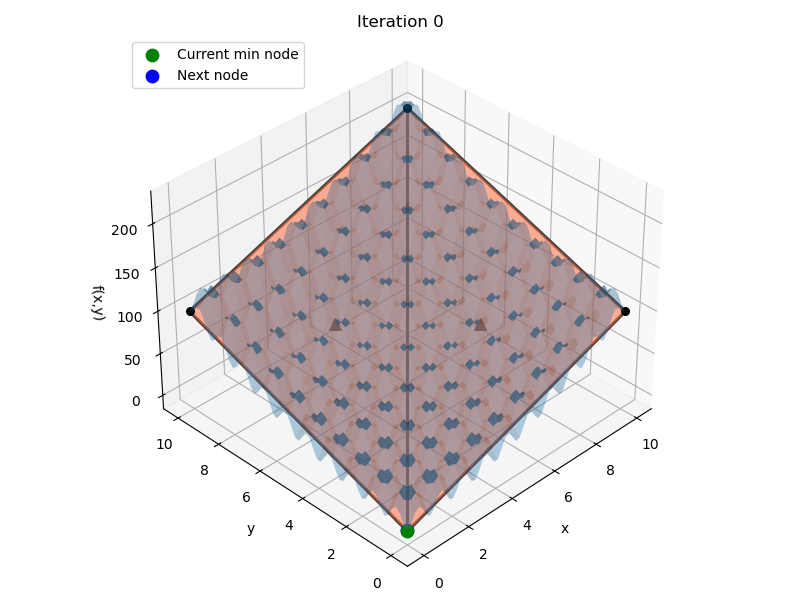

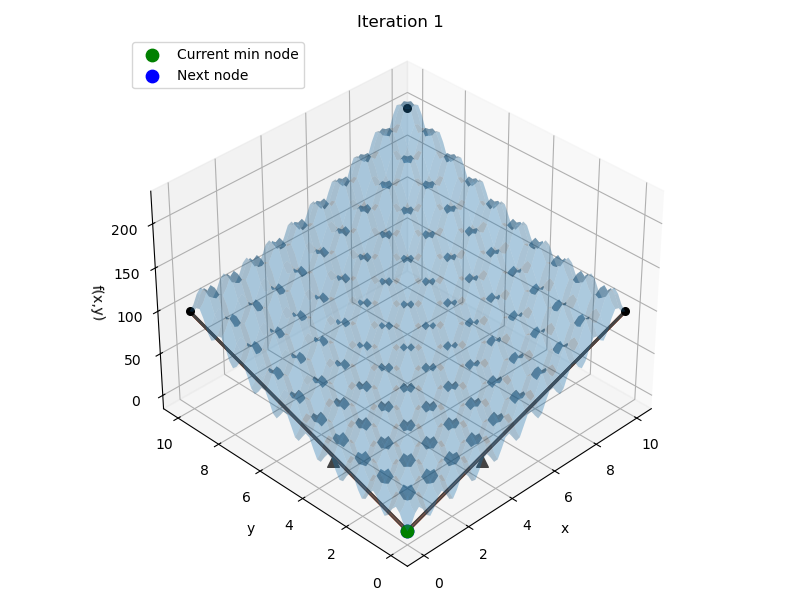

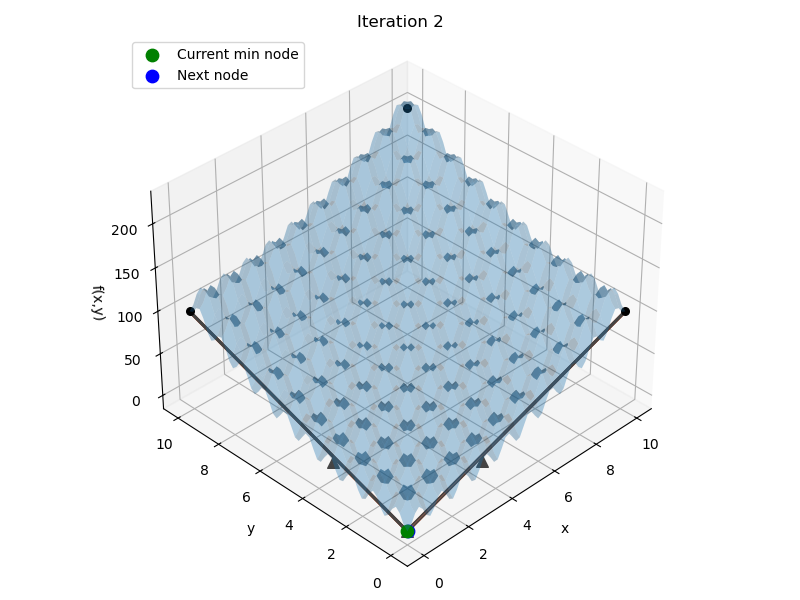

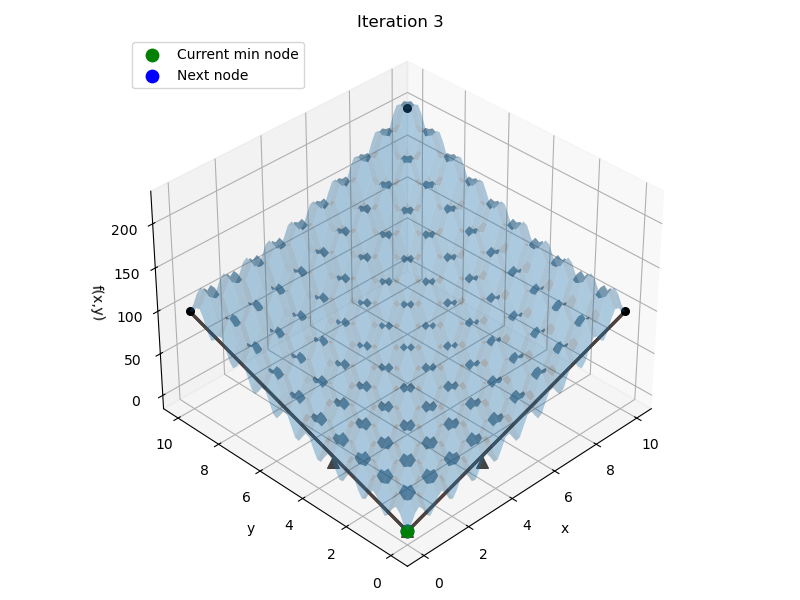

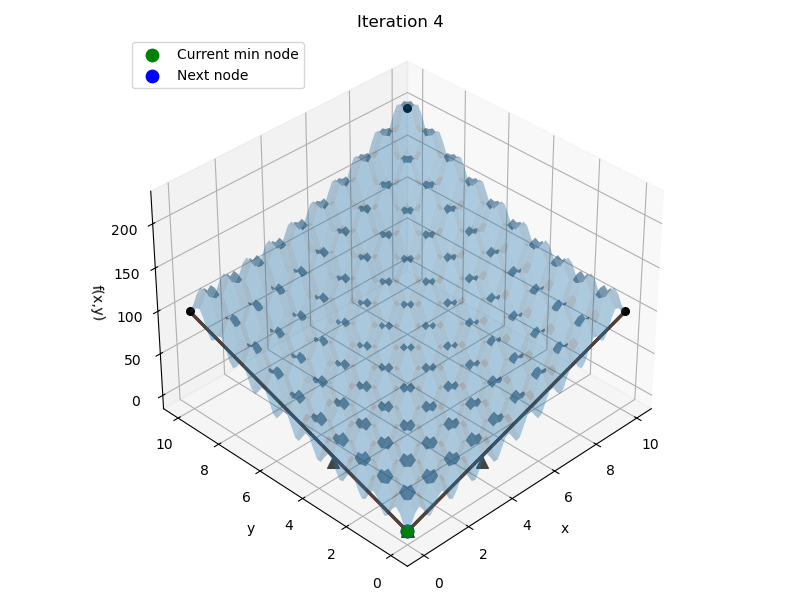

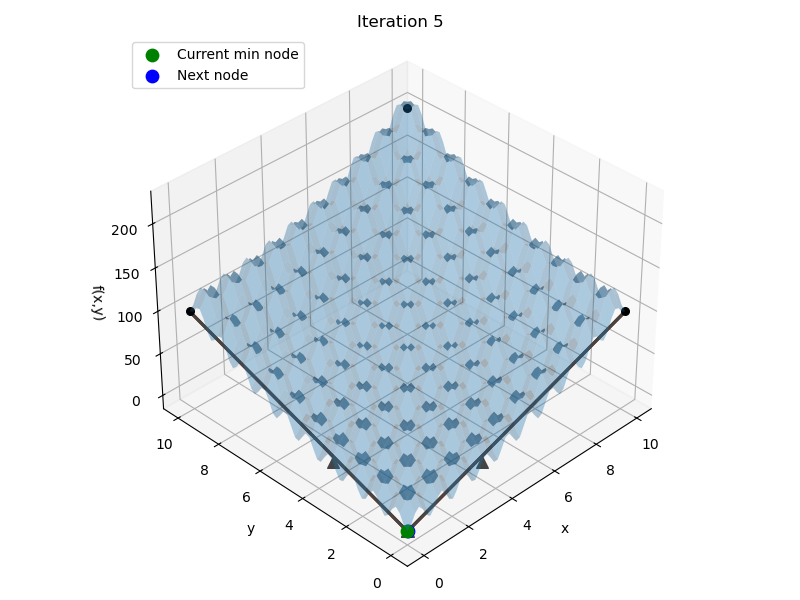

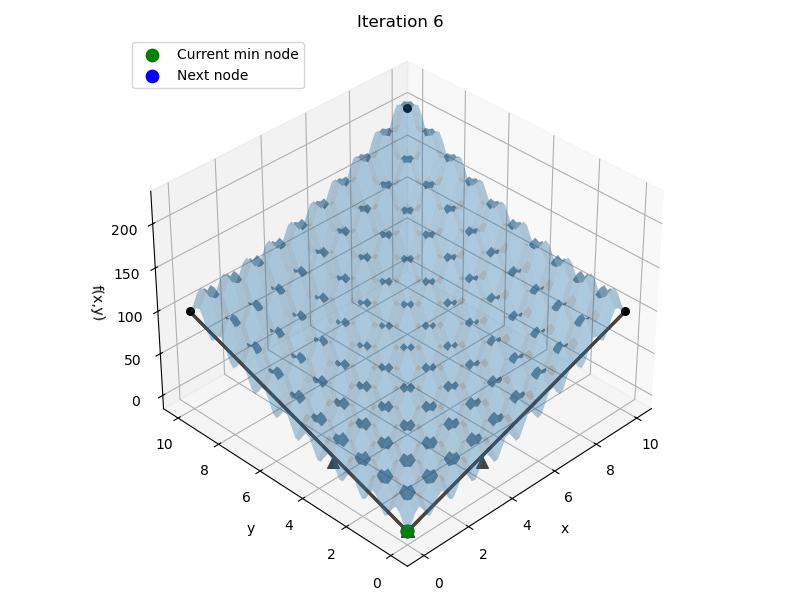

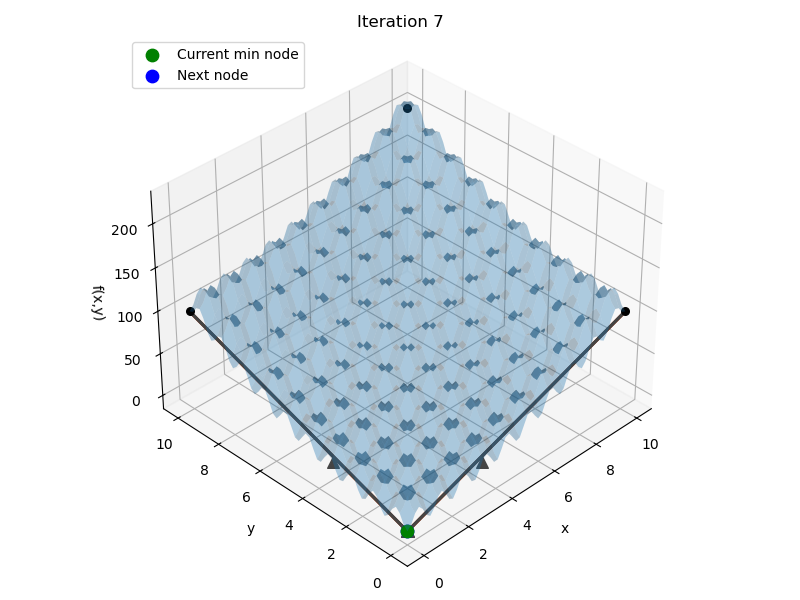

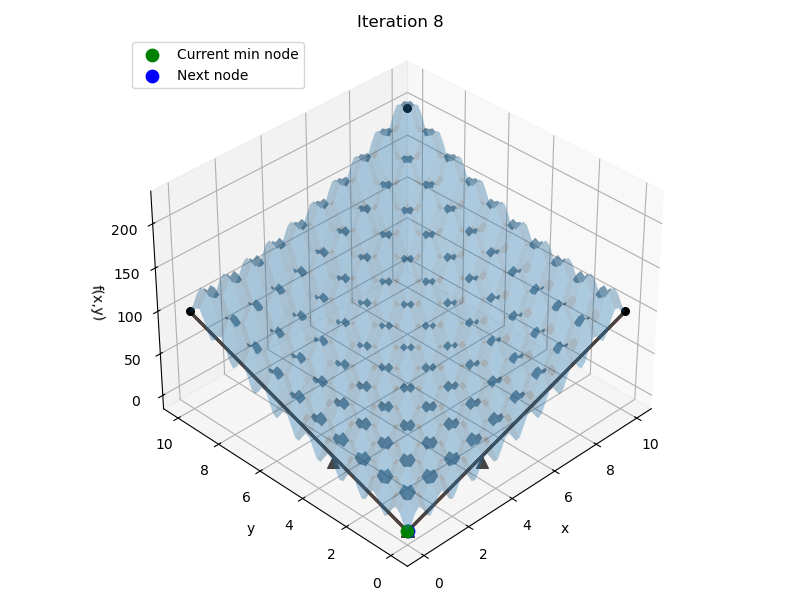

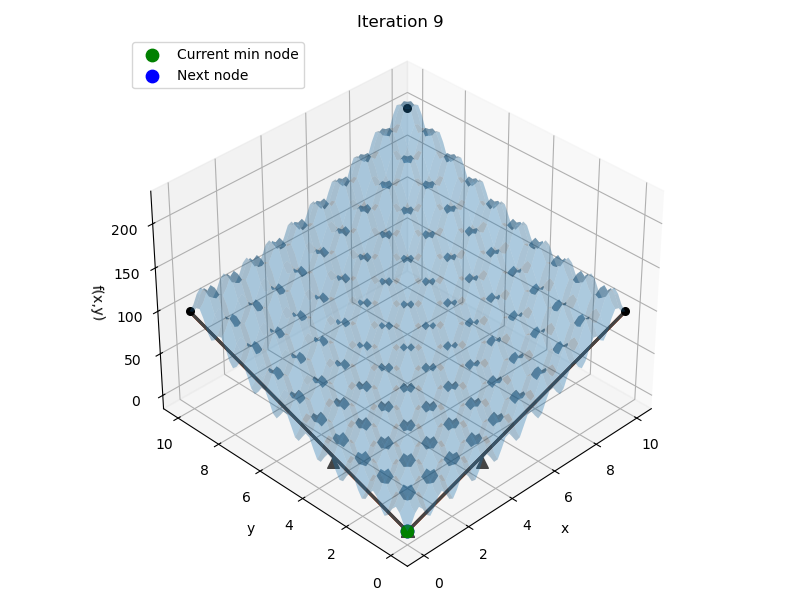

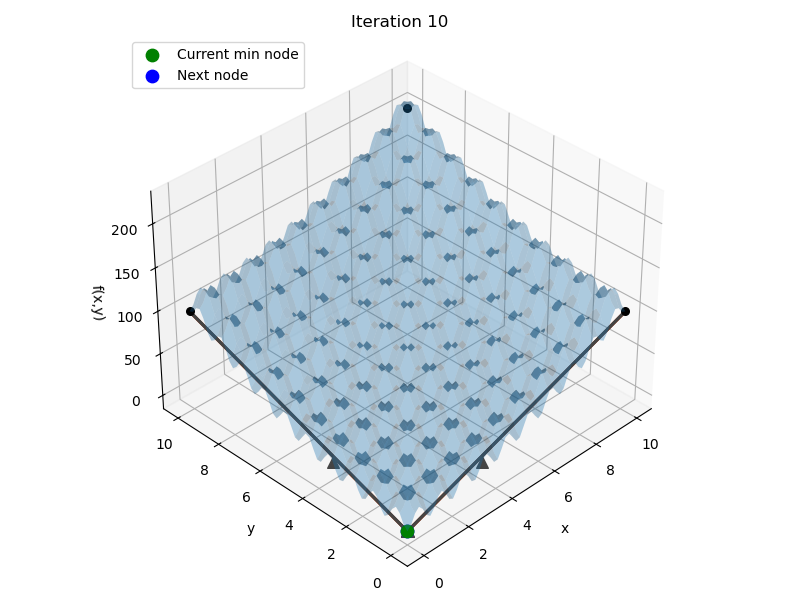

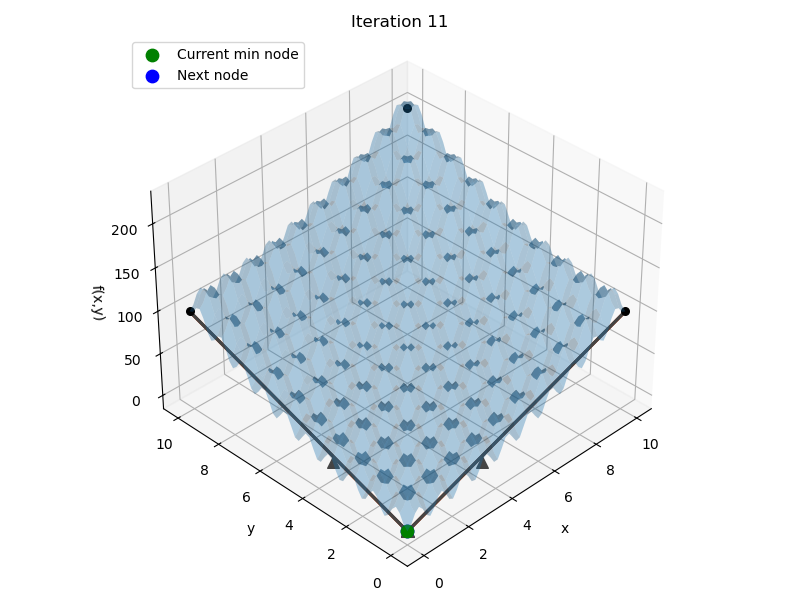

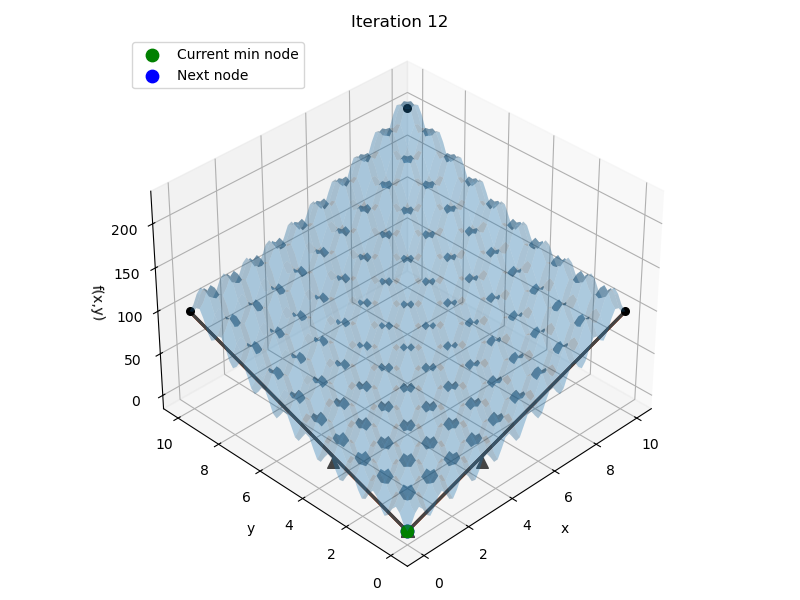

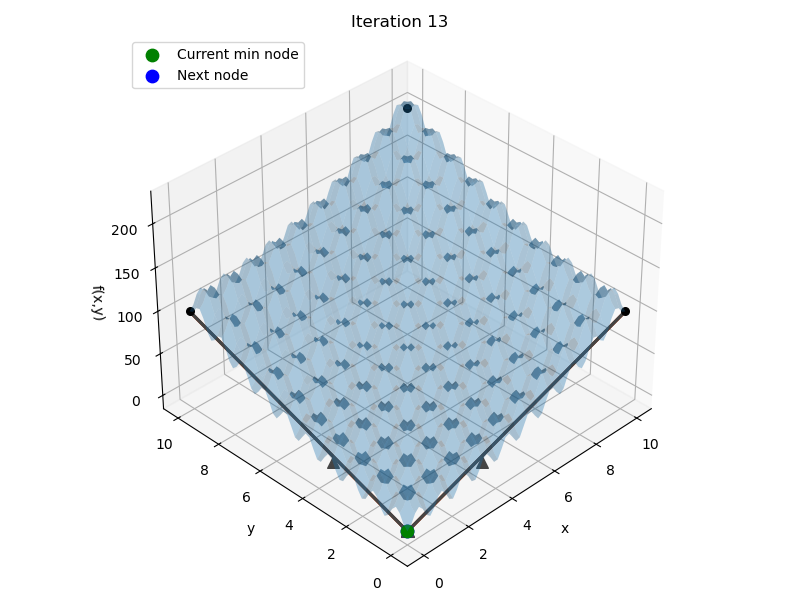

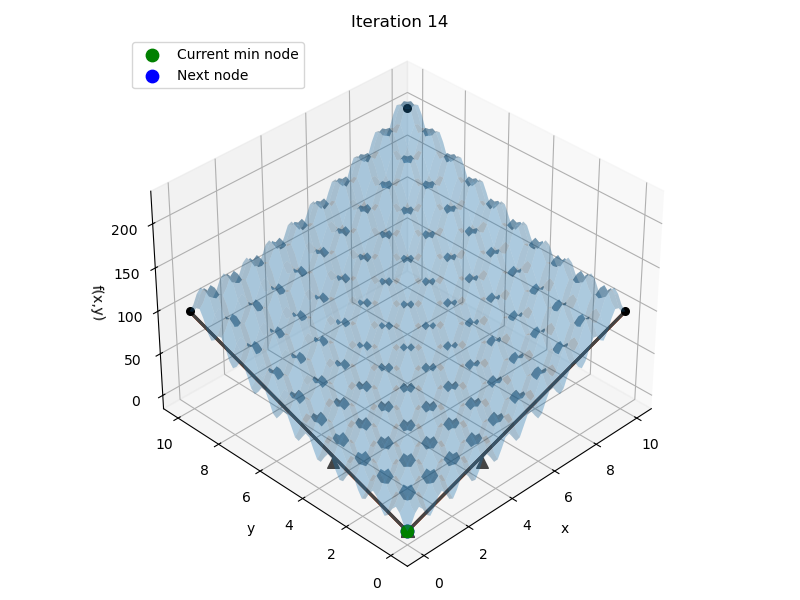

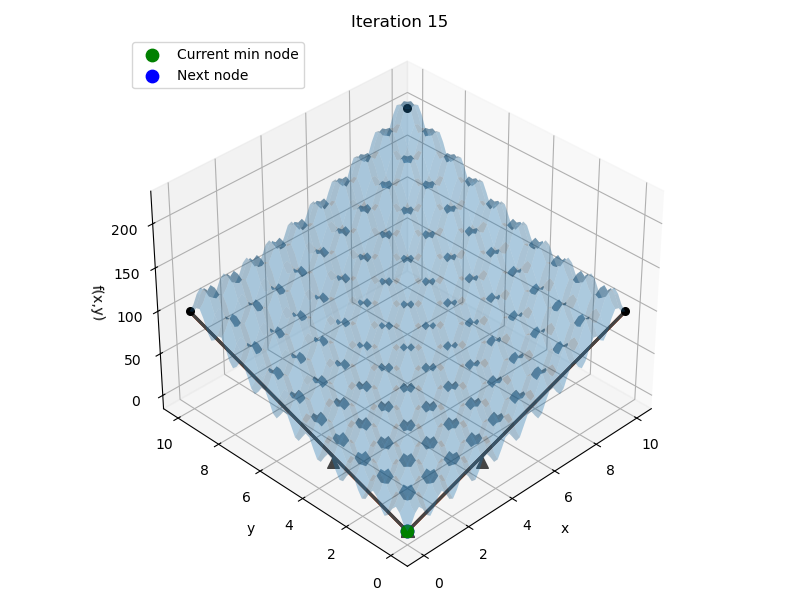

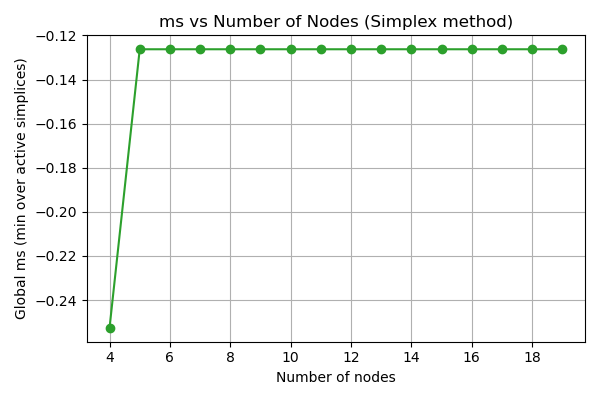


==== Summary Table ====
   Nodes |           ms |           LB |           UB
-----------------------------------------------------
       4 |      -0.2526 |      -0.2526 |       0.0000
       5 |      -0.1263 |      -0.1263 |       0.0000
       6 |      -0.1263 |      -0.0633 |       0.0000
       7 |      -0.1263 |      -0.0630 |       0.0000
       8 |      -0.1263 |      -0.0317 |       0.0000
       9 |      -0.1263 |      -0.0158 |       0.0000
      10 |      -0.1263 |      -0.0158 |       0.0000
      11 |      -0.1263 |      -0.0079 |       0.0000
      12 |      -0.1263 |      -0.0039 |       0.0000
      13 |      -0.1263 |      -0.0039 |       0.0000
      14 |      -0.1263 |      -0.0020 |       0.0000
      15 |      -0.1263 |      -0.0010 |       0.0000
      16 |      -0.1263 |      -0.0010 |       0.0000
      17 |      -0.1263 |      -0.0005 |       0.0000
      18 |      -0.1263 |      -0.0002 |       0.0000
      19 |      -0.1263 |      -0.0002 |       0.0000
---

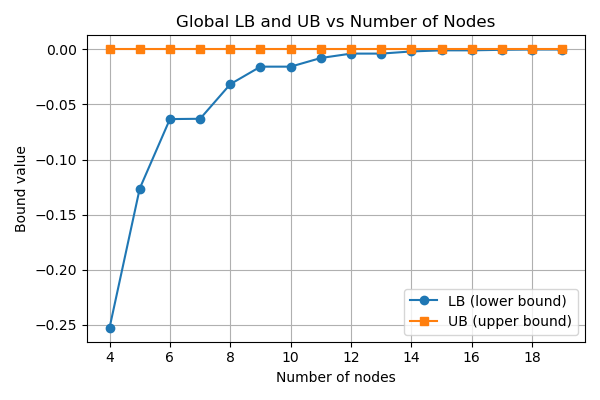

In [17]:
def drop_simplex_stuff(m):
    for nm in ['lam','lam_sum','x_link_x','x_link_y','As','As_con','obj']:
        if hasattr(m, nm):
            m.del_component(nm)

# ======== 每个三角形里求 ms、LB、UB ========
def minimize_on_each_triangle(nodes, values, solver='ipopt', tee=False):
    pts  = np.asarray(nodes, dtype=float)   # (N,2)
    vals = np.asarray(values, dtype=float)  # (N,)
    tri = Delaunay(pts)                     # tri.simplices: (K,3)

    m = build_model()
    opt = pyo.SolverFactory(solver)
    if solver == "gurobi":
        opt.options["NonConvex"] = 2


    results = []
    for k, simp in enumerate(tri.simplices):
        verts = pts[simp]     # (3,2)
        fverts= vals[simp]    # (3,)

        # 重心变量 lam_j >=0, sum lam =1
        m.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
        m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(3)) == 1.0)

        # x = sum lam_j * v_jx,  y = sum lam_j * v_jy
        m.x_link_x = pyo.Constraint(expr=m.x == sum(m.lam[j]*float(verts[j,0]) for j in range(3)))
        m.x_link_y = pyo.Constraint(expr=m.y == sum(m.lam[j]*float(verts[j,1]) for j in range(3)))

        # As = sum lam_j * f(v_j)
        m.As = pyo.Var()
        m.As_con = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(fverts[j]) for j in range(3)))

        # 目标：min f(x,y) - As
        m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)

        x_ms = np.array([pyo.value(m.x), pyo.value(m.y)], dtype=float)
        ms_val = float(pyo.value(m.obj))     # min_x [f - As]
        f_at_x_ms = f_true_numpy(x_ms)

        # LB = min As + ms = min f(顶点) + ms
        LB = float(np.min(fverts) + ms_val)
        # UB（报告用） = min( f(顶点), f(x_ms) )
        UB = float(min(np.min(fverts), f_at_x_ms))

        results.append({
            "simplex_index": int(k),
            "vertices_index": simp.tolist(),
            "verts": verts,
            "fverts": fverts,
            "x_ms": x_ms,
            "ms": ms_val,
            "LB": LB,
            "UB": UB,
            "f(x_ms)": f_at_x_ms,
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

        drop_simplex_stuff(m)

    return tri, results

def compute_lb_min_node_max_ms(nodes, values, per_tri):
    """
    根据你的新口径计算本轮全局 LB：
      LB_iter = f(v*) + max{ ms_triangle | v* 属于该三角形 }
    若极少数退化情形找不到包含 v* 的三角形（理论上不该发生），
    就回退为原口径：min_tri (min(fverts) + ms).
    """
    idx_min = int(np.argmin(values))
    ms_candidates = [r['ms'] for r in per_tri if idx_min in r['vertices_index']]
    if ms_candidates:
        return float(values[idx_min] + max(ms_candidates)), idx_min, float(max(ms_candidates))
    # fallback（几乎不会触发）
    fallback = float(min(r['LB'] for r in per_tri))
    return fallback, idx_min, float('nan')


# ======== 在单形法运行结束后，统计 LB / ms 并绘图 ========
def analyze_singlex_results(max_nodes=10):
    # 运行一次完整的单形法，记录每轮 global LB 与 ms
    LB_hist, ms_hist, node_count = [], [], []
    nodes = [
        np.array([0.0, 0.0]),
        np.array([0.0,10.0]),
        np.array([10.0,0.0]),
        np.array([10.0,10.0]),
    ]
    values = [f_true_numpy(p) for p in nodes]
    it = 0

    while len(nodes) < max_nodes:
        tri, per_tri = minimize_on_each_triangle(nodes, values, solver='ipopt', tee=False)

        # 全局剪枝 UB（当前节点集的最小 f 值）
        UB_prune = float(np.min(values))
        # 新口径：最小值节点 v* 的 f(v*) + max_{Δ∋v*} ms_Δ
        LB_iter, idx_min_node, ms_chosen = compute_lb_min_node_max_ms(nodes, values, per_tri)

        # ms = 所有单形中 min(ms)
        ms_iter = min(r['ms'] for r in per_tri)

        LB_hist.append(LB_iter)
        ms_hist.append(ms_iter)
        node_count.append(len(nodes))

        # 加点
        best_tri = min(per_tri, key=lambda r: r['ms'])
        new_node = np.array(best_tri['x_ms'], float)
        if any(np.linalg.norm(new_node - q) < 1e-6 for q in nodes):
            break
        nodes.append(new_node)
        values.append(f_true_numpy(new_node))
        it += 1
        if len(nodes) >= max_nodes:
            break

    # ======== 画图 ========
    plt.figure(figsize=(6,4))
    plt.plot(node_count, LB_hist, marker='o')
    plt.xlabel("Number of nodes")
    plt.ylabel("Global LB")
    plt.title("LB vs Number of Nodes (Simplex method)")
    plt.grid(True)
    plt.tight_layout()

    plt.figure(figsize=(6,4))
    plt.plot(node_count, ms_hist, marker='o')
    plt.xlabel("Number of nodes")
    plt.ylabel("Global ms (min over active simplices)")
    plt.title("ms vs Number of Nodes (Simplex method)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return node_count, LB_hist, ms_hist

def pick_candidate_by_ms_rank(per_tri, nodes, min_dist=1e-6, descending=False):
    """
    在 per_tri 中按 ms 排序（默认从大到小），依次找与已有 nodes 距离>=min_dist 的 x_ms。
    返回: new_node(np.array([x,y])), used_rank(int), used_ms(float)
    若所有候选都过近，则返回 None, None, None 让主流程采取 fallback（比如放宽阈值或改用几何替代）。
    """
    # 排序：ms 最大→最小（descending=True）；若想回到“ms 最小优先”，把 descending=False
    cands = sorted(per_tri, key=lambda r: r['ms'], reverse=descending)

    def ok(p):
        return all(np.linalg.norm(p - q) >= min_dist for q in nodes)

    for rank, r in enumerate(cands, start=1):
        p = np.array(r['x_ms'], float)
        if ok(p):
            return p, rank, float(r['ms'])

    return None, None, None

# ======== 打印“列=三角形”的表格 ========
def print_per_triangle_table(results, active_mask):
    """
    严格对齐 + 整列着色版本：
      - 列=三角形；第1行=UB，第2行=LB，第3行=ms
      - active 列整列红色（含表头与该列的所有单元格）
      - 使用 ANSI 颜色（Windows 旧 cmd 需 colorama.init()）
    """
    # 1) 整理数据（保持按 simplex_index 的顺序）
    results = sorted(results, key=lambda r: r["simplex_index"])
    simplex_ids = [r["simplex_index"] for r in results]
    active_set = {sid for sid in simplex_ids if active_mask[sid]}

    # 构建纯文本表（不带颜色，用来计算宽度）
    header = ["row\\simp"] + [f"T{sid}{'*' if sid in active_set else ''}" for sid in simplex_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.6f}" for r in results],
        ["LB"] + [f"{r['LB']:.6f}" for r in results],
        ["ms"] + [f"{r['ms']:.3e}" for r in results],
    ]
    table = [header] + rows

    # 2) 计算每一列的最大宽度（纯文本宽度）
    ncols = len(header)
    colw = [0]*ncols
    for c in range(ncols):
        colw[c] = max(len(str(row[c])) for row in table) + 2  # 预留空格

    # 3) 打印（先 padding，再套颜色 → 颜色码不影响对齐）
    RED = "\033[31m"
    RESET = "\033[0m"

    def colorize_if_active(col_idx: int, s: str) -> str:
        # col_idx>0 才对应某个 simplex 列；col 0 是行名
        if col_idx == 0:
            return s
        sid = simplex_ids[col_idx-1]
        return f"{RED}{s}{RESET}" if sid in active_set else s

    # 表头
    header_line = "".join(str(header[c]).ljust(colw[c]) if c == 0
                          else colorize_if_active(c, str(header[c]).ljust(colw[c]))
                          for c in range(ncols))
    print("\n== Per-triangle summary ==")
    print(header_line)

    # 分隔线
    print("-" * sum(colw))

    # 数据行
    for r in rows:
        line = []
        for c in range(ncols):
            cell = str(r[c])
            # 首列左对齐，其它列右对齐更好看
            padded = cell.ljust(colw[c]) if c == 0 else cell.rjust(colw[c])
            line.append(colorize_if_active(c, padded))
        print("".join(line))

    print("(红色列 = active；第1行=UB，第2行=LB，第3行=ms)\n")



# ======== 绘图：曲面 + 节点 + active 三角形 ========
def plot_iteration(iter_id, nodes, tri, active_mask,
                   grid_n=60, elev=35, azim=-135,
                   min_node=None, new_node=None,
                   per_tri=None):
    nodes = np.asarray(nodes, float)

    # === 颜色与线宽（方案一） ===
    COLOR_SURFACE = 'C0'           # 原函数曲面：保留蓝色
    COLOR_NODE_EDGES = '#444444'   # 原函数上的节点连线（active）
    COLOR_PIECE = '#ff7043'        # As+ms 分片（面+边，active）
    LW_MAIN = 2.2                  # 节点连线与分片边线统一粗度

    # --- 原函数栅格 ---
    xs = np.linspace(0, 10, grid_n)
    ys = np.linspace(0, 10, grid_n)
    XX, YY = np.meshgrid(xs, ys)
    # 用双高斯坑
    ZZ = np.zeros_like(XX)
    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            ZZ[i,j] = f_true_numpy([XX[i,j], YY[i,j]])

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    # 原函数曲面（蓝色，半透明）
    ax.plot_surface(XX, YY, ZZ, alpha=0.35, linewidth=0, antialiased=True, color=COLOR_SURFACE)

    # === 只画 active 分片：As+ms（面 + 边） ===
    if per_tri is not None and len(per_tri) > 0 and tri is not None:
        faces = []
        # 先收集面
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]     # (3,2)
            fverts   = r["fverts"]    # (3,)
            ms_val   = r["ms"]
            tri_xyz  = [(verts_xy[i,0], verts_xy[i,1], float(fverts[i] + ms_val)) for i in range(3)]
            faces.append(tri_xyz)

        if faces:
            coll = Poly3DCollection(faces, facecolors=[COLOR_PIECE],
                                    edgecolors='none', alpha=0.55)
            ax.add_collection3d(coll)

        # 再为每个 active 分片画“贴在 As+ms 上”的边线（与节点连线同粗）
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]
            fverts   = r["fverts"]
            ms_val   = r["ms"]
            # 三条边（在 As+ms 面上）
            for i in range(3):
                a_xy = verts_xy[i]
                b_xy = verts_xy[(i+1) % 3]
                za = float(fverts[i] + ms_val)
                zb = float(fverts[(i+1) % 3] + ms_val)
                ax.plot([a_xy[0], b_xy[0]], [a_xy[1], b_xy[1]], [za, zb],
                        lw=LW_MAIN, c=COLOR_PIECE)

    # 所有节点：黑点
    node_z = np.array([f_true_numpy(p) for p in nodes])
    ax.scatter(nodes[:,0], nodes[:,1], node_z, s=30, c='k', depthshade=False)

    # === 原函数上的“节点连线”：只画 active 三角形的边，颜色改为深灰，粗度与分片边一致 ===
    if tri is not None:
        for k, simp in enumerate(tri.simplices):
            if not active_mask.get(k, False):
                continue
            verts_xy = tri.points[simp]
            for i in range(3):
                a, b = verts_xy[i], verts_xy[(i+1) % 3]
                ax.plot([a[0], b[0]], [a[1], b[1]],
                        [f_true_numpy(a), f_true_numpy(b)],
                        lw=LW_MAIN, c=COLOR_NODE_EDGES)

            # active 三角形质心标记（可留可去）
            centroid = np.mean(verts_xy, axis=0)
            ax.scatter([centroid[0]], [centroid[1]], [f_true_numpy(centroid)],
                       marker='^', c=COLOR_NODE_EDGES, s=70, depthshade=False)

    # 绿色点：当前最小值节点
    if min_node is not None:
        ax.scatter([min_node[0]], [min_node[1]], [f_true_numpy(min_node)],
                   color='g', s=80, marker='o', label='Current min node')

    # 蓝色点：下一轮将加入的新节点
    if new_node is not None:
        ax.scatter([new_node[0]], [new_node[1]], [f_true_numpy(new_node)],
                   color='b', s=80, marker='o', label='Next node')

    ax.set_title(f"Iteration {iter_id}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")
    ax.legend(loc='upper left')
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


def plot_convergence(hist, prec=4):
    import matplotlib.pyplot as plt

    x  = hist["node_count"]
    LB = hist["LB_hist"]
    UB = hist["UB_hist"]
    ms = hist["ms_hist"]

    # ---- 图1：LB 与 UB ----
    plt.figure(figsize=(6,4))
    plt.plot(x, LB, marker='o', label="LB (lower bound)")
    plt.plot(x, UB, marker='s', label="UB (upper bound)")
    plt.xlabel("Number of nodes")
    plt.ylabel("Bound value")
    plt.title("Global LB and UB vs Number of Nodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # ---- 图2：ms 收敛 ----
    plt.figure(figsize=(6,4))
    plt.plot(x, ms, marker='o', color='C2')
    plt.xlabel("Number of nodes")
    plt.ylabel("Global ms (min over active simplices)")
    plt.title("ms vs Number of Nodes (Simplex method)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- 表格打印 ----
    print("\n==== Summary Table ====")
    fmt = f"{{:.{prec}f}}"  # 动态控制小数位
    header = f"{'Nodes':>8s} | {'ms':>12s} | {'LB':>12s} | {'UB':>12s}"
    print(header)
    print("-" * len(header))
    for n, m, lb, ub in zip(x, ms, LB, UB):
        print(f"{n:8d} | {fmt.format(m):>12s} | {fmt.format(lb):>12s} | {fmt.format(ub):>12s}")
    print("-" * len(header))
    print(f"{'Total':>8s} | {len(x):>12d}")




# ======== 主循环 ========
def run_case(max_nodes=10, solver='ipopt', tee=False, plot_grid_n=60,
             record_history=True, make_3d_plots=True,
             only_from_active=True, min_dist=1e-4, active_tol=1e-8):
    """
    only_from_active: True 则新点只在 active 单形中选择；若本轮无 active，则回退到全体单形
    min_dist:        与已有节点的最小间距阈值（去重）
    active_tol:      判定 active 的容差：LB <= UB_global + active_tol
    """
    # 初始四角
    nodes = [np.array([0.0,0.0]), np.array([0.0,10.0]),
             np.array([10.0,0.0]), np.array([10.0,10.0])]
    values = [f_true_numpy(p) for p in nodes]

    # 历史
    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []

    it = 0
    while len(nodes) < max_nodes:
        tri, per_tri = minimize_on_each_triangle(nodes, values, solver=solver, tee=tee)

        # 本轮全局 UB（基于现有节点的最小真实值）
        UB_global = float(np.min(values))

        # 你的口径：min-node 的 f(v*) + 其相邻单形的 max ms
        LB_iter, idx_min_node, ms_chosen = compute_lb_min_node_max_ms(nodes, values, per_tri)

        # 记录一个“ms 指标”：所有单形的最小 ms（你当前用法）
        ms_iter = min(r['ms'] for r in per_tri)

        if record_history:
            LB_hist.append(LB_iter)
            UB_hist.append(UB_global)
            ms_hist.append(ms_iter)
            node_count.append(len(nodes))

        # 计算 active 掩码与候选集合
        active_mask = { r['simplex_index']: (r['LB'] <= UB_global + active_tol) for r in per_tri }
        active_tris = [r for r in per_tri if r['LB'] <= UB_global + active_tol]
        candidates = active_tris if (only_from_active and len(active_tris) > 0) else per_tri
        if only_from_active and len(active_tris) == 0:
            print(f"[warn] No active simplices this round (tol={active_tol:g}); fall back to all simplices.")

        # 选新点：在 candidates 中按 ms 排序（ms 最小优先）
        new_node, used_rank, used_ms = pick_candidate_by_ms_rank(
            candidates, nodes, min_dist=min_dist, descending=False
        )
        if new_node is None:
            print("All candidates too close; stop.")
            break

        # 可视化
        if make_3d_plots:
            plot_iteration(it, nodes, tri, active_mask,
                           grid_n=plot_grid_n,
                           min_node=nodes[idx_min_node],
                           new_node=new_node, per_tri=per_tri)

        # 去重后加入一次
        if any(np.linalg.norm(new_node - q) < min_dist for q in nodes):
            print("New node too close to an existing node; stop.")
            break
        nodes.append(new_node)
        values.append(f_true_numpy(new_node))

        it += 1

    return {
        "nodes": np.array(nodes), "values": np.array(values),
        "LB_hist": LB_hist, "UB_hist": UB_hist, "ms_hist": ms_hist,
        "node_count": node_count
    }




# ======== 调用示例 ========
if __name__ == "__main__":
    solver      = "ipopt"
    max_nodes   = 20
    plot_3d     = True
    record_hist = True

    hist_simp = run_case(
        max_nodes=max_nodes,
        solver=solver,
        tee=False,
        plot_grid_n=60,
        record_history=record_hist,
        make_3d_plots=plot_3d
    )

    # 默认四位小数，可改成比如 prec=6
    plot_convergence(hist_simp, prec=4)

    nodes  = hist_simp["nodes"]
    values = hist_simp["values"]
    print("\n==== Done ====")
    print(f"Total nodes: {len(nodes)}")
    print(f"Best f among nodes: {np.min(values):.6f}")


In [2]:
import numpy as np
from scipy.spatial import Delaunay
import pyomo.environ as pyo
import matplotlib.pyplot as plt

# ======== 真实目标（与你给的 model 完全一致） ========
def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return 2.0*(x - 3.0)**2 + 3.0*(y - 5.0)**2

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m

def f_true_expr(m):
    return 2*(m.x - 3)**2 + 3*(m.y - 5)**2

def _drop_local(m):
    for nm in ['lam','lam_sum','x_link_x','x_link_y','As','As_con','obj']:
        if hasattr(m, nm):
            m.del_component(nm)

# ======== 在单个三角形内求 ms 与相关量 ========
def solve_ms_on_triangle(verts_xy, fverts, solver='ipopt', tee=False):
    """
    verts_xy: (3,2) 三角形顶点坐标
    fverts:   (3,)  顶点真实值 f(v)
    返回：dict(ms, x_ms, LB_tri, UB_tri)
    """
    m = build_model()
    opt = pyo.SolverFactory(solver)

    # 重心变量
    m.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
    m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(3)) == 1.0)

    # x, y 与顶点的线性链接
    m.x_link_x = pyo.Constraint(expr=m.x == sum(m.lam[j]*float(verts_xy[j,0]) for j in range(3)))
    m.x_link_y = pyo.Constraint(expr=m.y == sum(m.lam[j]*float(verts_xy[j,1]) for j in range(3)))

    # As = 顶点 f 的线性插值
    m.As = pyo.Var()
    m.As_con = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(fverts[j]) for j in range(3)))

    # 目标：min f - As
    m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

    res = opt.solve(m, tee=tee)

    x_ms = np.array([pyo.value(m.x), pyo.value(m.y)], dtype=float)
    ms_val = float(pyo.value(m.obj))               # min_x [f - As]
    f_at_x_ms = f_true_numpy(x_ms)

    # 该三角形诱导的下界 / 上界（用于全局 LB/UB 组成）
    LB_tri = float(np.min(fverts) + ms_val)        # min As + ms = min f(verts) + ms
    UB_tri = float(min(np.min(fverts), f_at_x_ms)) # 可行上界：顶点 & x_ms

    _drop_local(m)
    return {
        "ms": ms_val,
        "x_ms": x_ms,
        "LB_tri": LB_tri,
        "UB_tri": UB_tri,
        "status": str(res.solver.status),
        "term": str(res.solver.termination_condition),
    }

# ======== “原来方法”：每轮只取全局最小 ms 的点加入 ========
def run_global_method(max_nodes=10, solver='ipopt', tee=False, verbose=True):
    # 初始四角点
    nodes = [
        np.array([0.0, 0.0]),
        np.array([0.0,10.0]),
        np.array([10.0,0.0]),
        np.array([10.0,10.0]),
    ]
    values = [f_true_numpy(p) for p in nodes]

    LB_hist = []
    ms_hist = []
    nodes_count_hist = []

    it = 0
    while len(nodes) < max_nodes:
        pts = np.asarray(nodes, float)
        tri = Delaunay(pts)

        # 遍历所有三角形，求每个三角形的 ms 与三角形下界
        tri_results = []
        for simp in tri.simplices:
            verts_xy = pts[simp]                   # (3,2)
            fverts   = np.array([values[idx] for idx in simp], float)  # (3,)
            r = solve_ms_on_triangle(verts_xy, fverts, solver=solver, tee=tee)
            tri_results.append(r)

        # 本轮“全局”指标
        ms_global = min(r["ms"] for r in tri_results)
        LB_global = min(r["LB_tri"] for r in tri_results)

        ms_hist.append(ms_global)
        LB_hist.append(LB_global)
        nodes_count_hist.append(len(nodes))

        if verbose:
            print(f"Iter {it:02d} | nodes={len(nodes)} | ms={ms_global:.6e} | LB={LB_global:.6f}")

        # 选取全局最小 ms 的三角形对应的点作为新节点
        best_r = min(tri_results, key=lambda r: r["ms"])
        new_node = np.array(best_r["x_ms"], float)

        # 防止重复
        if any(np.linalg.norm(new_node - q) < 1e-8 for q in nodes):
            if verbose:
                print("New node too close to existing nodes; stop.")
            break

        nodes.append(new_node)
        values.append(f_true_numpy(new_node))
        it += 1

    return {
        "nodes": np.array(nodes),
        "values": np.array(values),
        "LB_hist": np.array(LB_hist, float),
        "ms_hist": np.array(ms_hist, float),
        "nodes_count_hist": np.array(nodes_count_hist, int),
    }

# ======== 画图：LB vs 节点数；ms vs 节点数 ========
def plot_histories(nodes_count_hist, LB_hist, ms_hist):
    plt.figure(figsize=(6,4))
    plt.plot(nodes_count_hist, LB_hist, marker='o')
    plt.xlabel("Number of nodes")
    plt.ylabel("Global LB")
    plt.title("LB vs number of nodes (global-min method)")
    plt.grid(True)
    plt.tight_layout()

    plt.figure(figsize=(6,4))
    plt.plot(nodes_count_hist, ms_hist, marker='o')
    plt.xlabel("Number of nodes")
    plt.ylabel("Global ms")
    plt.title("ms vs number of nodes (global-min method)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ======== 直接运行 ========
if __name__ == "__main__":
    max_nodes = 20
    out = run_global_method(max_nodes=max_nodes, solver="ipopt", tee=False, verbose=True)
    plot_histories(out["nodes_count_hist"], out["LB_hist"], out["ms_hist"])


ipopt


ApplicationError: No executable found for solver 'ipopt'

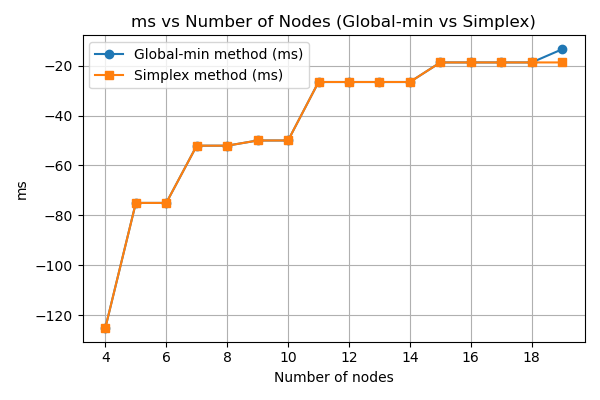

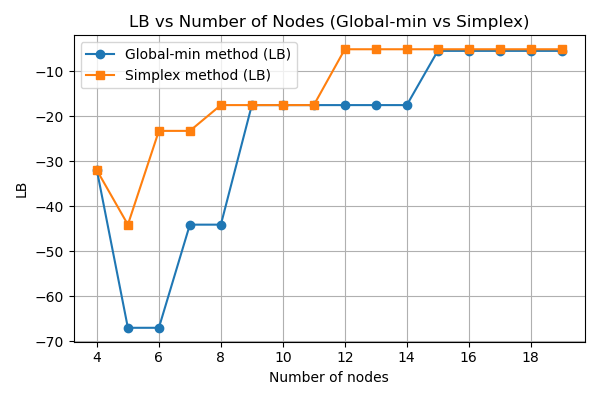

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 从全局法结果 out 提取序列 ----
node_count_global = np.asarray(out["nodes_count_hist"])
LB_hist_global    = np.asarray(out["LB_hist"])
ms_hist_global    = np.asarray(out["ms_hist"])

# ---- 将单形法结果转成 numpy ----
node_count_simplex = np.asarray(node_count_simplex)
LB_hist_simplex    = np.asarray(LB_hist_simplex)
ms_hist_simplex    = np.asarray(ms_hist_simplex)

# ---- 对齐横轴：仅保留两个方法都包含的节点数 ----
common_nodes = sorted(set(node_count_global.tolist()) & set(node_count_simplex.tolist()))

# 建立从“节点数→索引”的映射，便于抽取对应 y 值
idx_g = {n: i for i, n in enumerate(node_count_global)}
idx_s = {n: i for i, n in enumerate(node_count_simplex)}

LB_g = [LB_hist_global[idx_g[n]] for n in common_nodes]
LB_s = [LB_hist_simplex[idx_s[n]] for n in common_nodes]
ms_g = [ms_hist_global[idx_g[n]] for n in common_nodes]
ms_s = [ms_hist_simplex[idx_s[n]] for n in common_nodes]

# ---- 画 LB 对比 ----
plt.figure(figsize=(6,4))
plt.plot(common_nodes, LB_g, marker='o', label="Global-min method (LB)")
plt.plot(common_nodes, LB_s, marker='s', label="Simplex method (LB)")
plt.xlabel("Number of nodes")
plt.ylabel("LB")
plt.title("LB vs Number of Nodes (Global-min vs Simplex)")
plt.grid(True)
plt.legend()
plt.tight_layout()

# ---- 画 ms 对比 ----
plt.figure(figsize=(6,4))
plt.plot(common_nodes, ms_g, marker='o', label="Global-min method (ms)")
plt.plot(common_nodes, ms_s, marker='s', label="Simplex method (ms)")
plt.xlabel("Number of nodes")
plt.ylabel("ms")
plt.title("ms vs Number of Nodes (Global-min vs Simplex)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


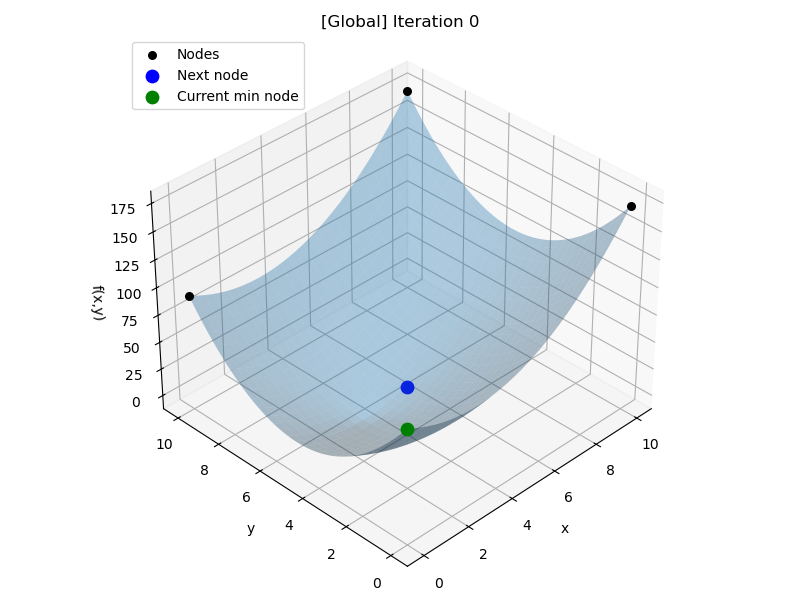

New node too close to an existing node; stop.


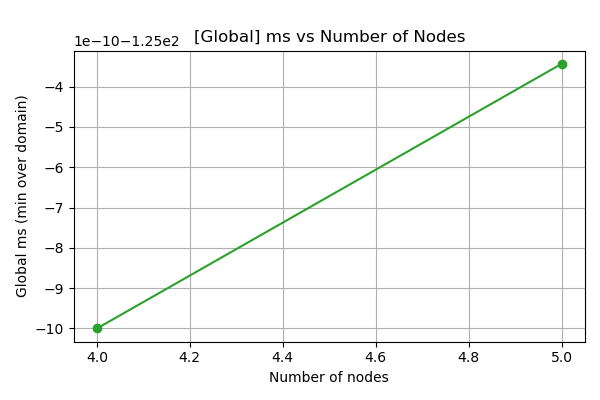


==== [Global] Summary Table ====
   Nodes |           ms |           LB |           UB
-----------------------------------------------------
       4 |    -125.0000 |     -32.0000 |      93.0000
       5 |    -125.0000 |    -117.0000 |       8.0000
-----------------------------------------------------
   Total |            2

==== [Global] Done ====
Total nodes: 5
Best f among nodes: 8.000000


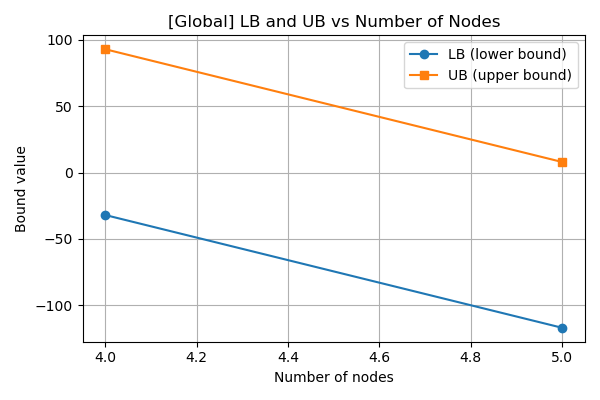

In [2]:
import numpy as np
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
%matplotlib widget

# ======== 真实函数（也是 obj_expr）========
def f_true_numpy(xy):
    x, y = float(xy[0]), float(xy[1])
    return 2.0*(x - 3.0)**2 + 3.0*(y - 5.0)**2

def build_boxed_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m

def f_true_expr(m):
    return 2*(m.x - 3)**2 + 3*(m.y - 5)**2

# ======== 全局（不用单形）最小化 ms = f(x,y) - As(x,y) ========
def global_min_gap(nodes, values, solver="ipopt", tee=False):
    """
    给定当前节点 nodes (N,2) 与其真实值 values (N,),
    在 [0,10]^2 内解：min f(x,y) - sum_j lam_j f_j
    s.t. lam_j >= 0, sum lam = 1, x = sum lam * xj, y = sum lam * yj.
    返回：
      x_ms: 使 gap 最小的点
      ms_val: 最小 gap
      As_at_x: As(x_ms)
      f_at_x: f(x_ms)
    """
    pts  = np.asarray(nodes, float)
    vals = np.asarray(values, float)
    N = len(pts)

    m = build_boxed_model()
    # lambda over all nodes
    m.lam = pyo.Var(range(N), domain=pyo.NonNegativeReals)
    m.As  = pyo.Var()

    # convexity & linkage
    m.c_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(N)) == 1.0)
    m.c_x   = pyo.Constraint(expr=m.x == sum(m.lam[j]*float(pts[j,0]) for j in range(N)))
    m.c_y   = pyo.Constraint(expr=m.y == sum(m.lam[j]*float(pts[j,1]) for j in range(N)))
    m.c_As  = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(vals[j]) for j in range(N)))

    # objective: min f(x,y) - As
    m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

    opt = pyo.SolverFactory(solver)
    res = opt.solve(m, tee=tee)

    x_ms = np.array([pyo.value(m.x), pyo.value(m.y)], float)
    f_at_x = f_true_numpy(x_ms)
    As_at_x = float(pyo.value(m.As))
    ms_val = float(f_at_x - As_at_x)

    return {
        "x_ms": x_ms,
        "ms": ms_val,
        "As_at_x": As_at_x,
        "f_at_x": f_at_x,
        "status": str(res.solver.status),
        "term": str(res.solver.termination_condition),
    }

# ======== 可视化（简单版）========
def plot_iteration_global(iter_id, nodes, new_node, grid_n=60, elev=35, azim=-135):
    nodes = np.asarray(nodes, float)
    xs = np.linspace(0, 10, grid_n)
    ys = np.linspace(0, 10, grid_n)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = 2.0*(XX-3.0)**2 + 3.0*(YY-5.0)**2

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(XX, YY, ZZ, alpha=0.35, linewidth=0, antialiased=True, color='C0')

    node_z = np.array([f_true_numpy(p) for p in nodes])
    ax.scatter(nodes[:,0], nodes[:,1], node_z, s=30, c='k', depthshade=False, label='Nodes')

    if new_node is not None:
        ax.scatter([new_node[0]],[new_node[1]],[f_true_numpy(new_node)],
                   color='b', s=80, marker='o', label='Next node')

    # 当前最佳节点
    best_idx = int(np.argmin(node_z))
    ax.scatter([nodes[best_idx,0]],[nodes[best_idx,1]],[node_z[best_idx]],
               color='g', s=80, marker='o', label='Current min node')

    ax.set_title(f"[Global] Iteration {iter_id}")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f(x,y)")
    ax.legend(loc='upper left')
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout(); plt.show()

# ======== 收敛曲线 ========
def plot_convergence(hist, prec=4):
    x  = hist["node_count"]
    LB = hist["LB_hist"]
    UB = hist["UB_hist"]
    ms = hist["ms_hist"]

    plt.figure(figsize=(6,4))
    plt.plot(x, LB, marker='o', label="LB (lower bound)")
    plt.plot(x, UB, marker='s', label="UB (upper bound)")
    plt.xlabel("Number of nodes"); plt.ylabel("Bound value")
    plt.title("[Global] LB and UB vs Number of Nodes")
    plt.legend(); plt.grid(True); plt.tight_layout()

    plt.figure(figsize=(6,4))
    plt.plot(x, ms, marker='o', color='C2')
    plt.xlabel("Number of nodes"); plt.ylabel("Global ms (min over domain)")
    plt.title("[Global] ms vs Number of Nodes")
    plt.grid(True); plt.tight_layout(); plt.show()

    print("\n==== [Global] Summary Table ====")
    fmt = f"{{:.{prec}f}}"
    header = f"{'Nodes':>8s} | {'ms':>12s} | {'LB':>12s} | {'UB':>12s}"
    print(header); print("-"*len(header))
    for n, m, lb, ub in zip(x, ms, LB, UB):
        print(f"{n:8d} | {fmt.format(m):>12s} | {fmt.format(lb):>12s} | {fmt.format(ub):>12s}")
    print("-"*len(header))
    print(f"{'Total':>8s} | {len(x):>12d}")

# ======== 主循环（老方法：不用单形，全域求 ms）========
def run_case_global(max_nodes=10, solver='ipopt', tee=False,
                    record_history=True, make_3d_plots=True,
                    min_dist=1e-4):
    # 初始四角
    nodes = [np.array([0.0,0.0]), np.array([0.0,10.0]),
             np.array([10.0,0.0]), np.array([10.0,10.0])]
    values = [f_true_numpy(p) for p in nodes]

    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []

    it = 0
    while len(nodes) < max_nodes:
        # 全域最小 gap
        res = global_min_gap(nodes, values, solver=solver, tee=tee)
        x_ms   = res["x_ms"]
        ms_val = res["ms"]

        # UB：当前节点上的最小 f
        UB_global = float(np.min(values))
        # LB：min_j f(v_j) + ms_global  （因为 min_x As(x) = min_j f(v_j)）
        LB_iter = float(np.min(values) + ms_val)

        if record_history:
            LB_hist.append(LB_iter)
            UB_hist.append(UB_global)
            ms_hist.append(ms_val)
            node_count.append(len(nodes))

        # 新点加入（去重）
        if any(np.linalg.norm(x_ms - q) < min_dist for q in nodes):
            print("New node too close to an existing node; stop.")
            break
        nodes.append(x_ms)
        values.append(f_true_numpy(x_ms))

        # 画图
        if make_3d_plots:
            plot_iteration_global(it, nodes[:-1], x_ms)

        it += 1

    return {
        "nodes": np.array(nodes), "values": np.array(values),
        "LB_hist": LB_hist, "UB_hist": UB_hist, "ms_hist": ms_hist,
        "node_count": node_count
    }

# ======== 调用示例 ========
if __name__ == "__main__":
    solver      = "gurobi"
    max_nodes   = 50
    plot_3d     = True
    record_hist = True

    hist = run_case_global(
        max_nodes=max_nodes,
        solver=solver,
        tee=False,
        record_history=record_hist,
        make_3d_plots=plot_3d,
        min_dist=1e-4
    )

    plot_convergence(hist, prec=4)

    nodes  = hist["nodes"]
    values = hist["values"]
    print("\n==== [Global] Done ====")
    print(f"Total nodes: {len(nodes)}")
    print(f"Best f among nodes: {np.min(values):.6f}")


In [29]:
import numpy as np
import matplotlib.pyplot as plt

def _as_positive_ms(ms_array, already_positive=False):
    ms_array = np.asarray(ms_array, float)
    return ms_array if already_positive else -ms_array

def _align_by_nodes(nodes_a, y_a, nodes_b, y_b):
    nodes_a = np.asarray(nodes_a, int)
    nodes_b = np.asarray(nodes_b, int)
    common = np.intersect1d(nodes_a, nodes_b)
    ia = {int(n): i for i, n in enumerate(nodes_a)}
    ib = {int(n): i for i, n in enumerate(nodes_b)}
    y_a2 = [y_a[ia[int(n)]] for n in common]
    y_b2 = [y_b[ib[int(n)]] for n in common]
    return common, np.asarray(y_a2, float), np.asarray(y_b2, float)

def plot_compare_LB_ms(res_plf, hist_simp, ms_plf_is_Q_minus_As=True, use_semilogy=True):
    # 分片法
    nodes_plf = np.asarray(res_plf.get("nodes_count") or list(range(len(res_plf["LB_history"]))), int)
    LB_plf    = np.asarray(res_plf["LB_history"], float)
    ms_plf    = _as_positive_ms(np.asarray(res_plf["ms_history"], float),
                                already_positive=not ms_plf_is_Q_minus_As)

    # 单形法
    nodes_s = np.asarray(hist_simp["node_count"], int)
    LB_s    = np.asarray(hist_simp["LB_hist"], float)
    ms_s    = _as_positive_ms(np.asarray(hist_simp["ms_hist"], float), already_positive=False)

    # 对齐横轴（只在共同节点数上比较）
    x_LB, LBp, LBs = _align_by_nodes(nodes_plf, LB_plf, nodes_s, LB_s)
    # ms 序列常从第一轮开始，单独对齐
    x_ms, msp, mss = _align_by_nodes(nodes_plf[:len(ms_plf)], ms_plf, nodes_s[:len(ms_s)], ms_s)

    # —— LB 对比 —— 
    plt.figure(figsize=(6,4))
    plt.plot(x_LB, LBp, marker='o', label='PLF - LB')
    plt.plot(x_LB, LBs, marker='s', label='Simplex - LB')
    plt.axhline(0.0, linestyle='--', linewidth=1, label='True optimum (0)')  # 可选：已知最优
    plt.xlabel("number of nodes"); plt.ylabel("LB")
    plt.title("LB vs number of nodes"); plt.grid(True); plt.legend(); plt.tight_layout()

    # —— ms 对比（正误差 As - Q，越低越好）——
    plt.figure(figsize=(6,4))
    if use_semilogy:
        plt.semilogy(x_ms, msp, marker='o', label='PLF - ms (As - Q)')
        plt.semilogy(x_ms, mss, marker='s', label='Simplex - ms (As - Q)')
    else:
        plt.plot(x_ms, msp, marker='o', label='PLF - ms (As - Q)')
        plt.plot(x_ms, mss, marker='s', label='Simplex - ms (As - Q)')
    plt.xlabel("number of nodes"); plt.ylabel("ms (positive)")
    plt.title("ms vs number of nodes"); plt.grid(True, which='both'); plt.legend(); plt.tight_layout()

    # 简短数值快照
    if len(x_LB):
        print(f"LB@last common node {x_LB[-1]}: PLF={LBp[-1]:.6g}, Simplex={LBs[-1]:.6g}")
    if len(x_ms):
        print(f"ms@last common node {x_ms[-1]}: PLF={msp[-1]:.6g}, Simplex={mss[-1]:.6g}")


k=  5  new_node=(5.0, 5.0)  ms=-125  LB=-32  UB=93
k=  6  new_node=(0.0, 5.0)  ms=-75  LB=-67  UB=8
k=  7  new_node=(10.0, 5.0)  ms=-75  LB=-67  UB=8
k=  8  new_node=(5.0, 0.8333333333333334)  ms=-52.0833  LB=-44.0833  UB=8
k=  9  new_node=(5.0, 9.166666666666666)  ms=-52.0833  LB=-44.0833  UB=8
k= 10  new_node=(5.0, 9.408383911415142e-06)  ms=-50.0001  LB=-42.0001  UB=8
k= 11  new_node=(5.0, 10.0)  ms=-50  LB=-42  UB=8
k= 12  new_node=(5.0, 0.0)  ms=-50  LB=-42  UB=8
k= 13  new_node=(8.020833333333584, 7.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 14  new_node=(1.9791666666664156, 7.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 15  new_node=(1.9791666666664174, 2.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 16  new_node=(8.020833333333583, 2.5)  ms=-26.5842  LB=-18.5842  UB=8
k= 17  new_node=(0.0, 7.5)  ms=-18.75  LB=-10.75  UB=8
k= 18  new_node=(10.0, 7.5)  ms=-18.75  LB=-10.75  UB=8
k= 19  new_node=(0.0, 2.5)  ms=-18.75  LB=-10.75  UB=8
k= 20  new_node=(10.0, 2.5)  ms=-18.75  LB=-10.75  UB=8
k= 21  new_

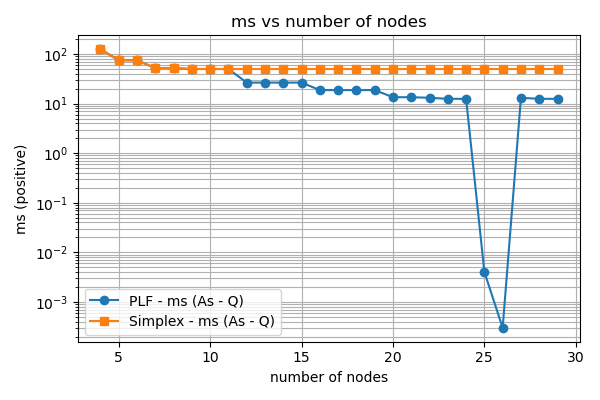

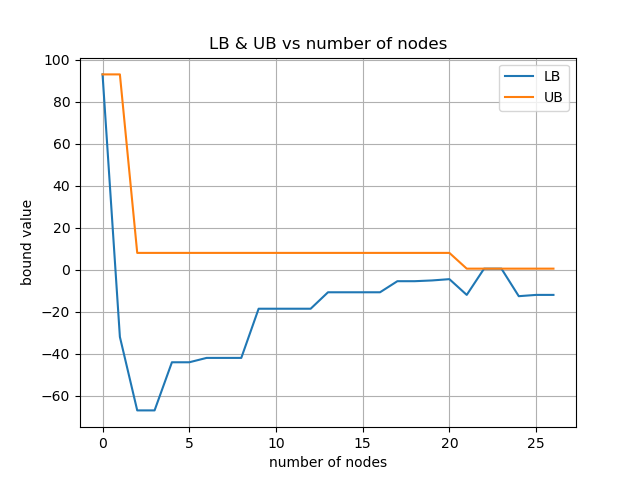

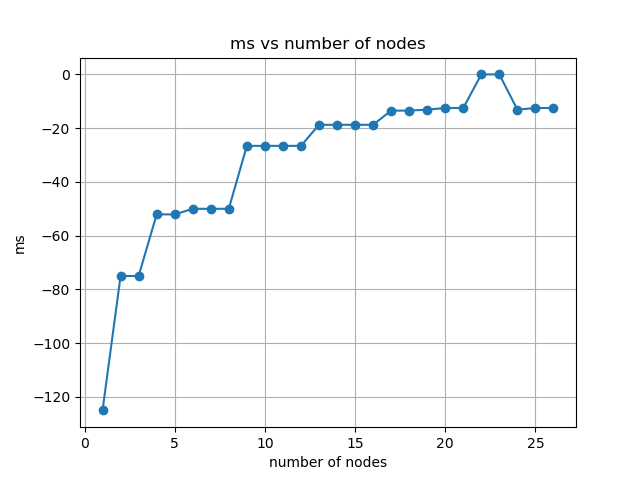

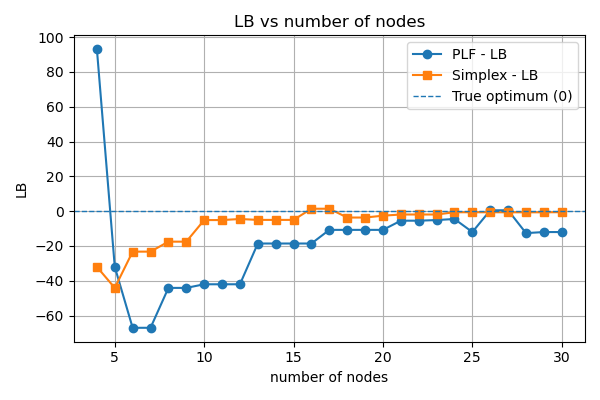

In [30]:
import pyomo.environ as pyo
from pyomo.contrib.piecewise import PiecewiseLinearFunction as PLF
from pyomo.core.base import TransformationFactory
from pyomo.opt import SolverStatus, TerminationCondition
import numpy as np
import matplotlib.pyplot as plt

# ============== 真函数 & 基础模型 ==============
def f_true_numpy(x, y):
    return 2.0*(x - 3.0)**2 + 3.0*(y - 5.0)**2

def build_model():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    m.obj_expr = pyo.Expression(expr=2.0*(m.x - 3.0)**2 + 3.0*(m.y - 5.0)**2)
    return m, [m.x, m.y]

# ============== 小工具 ==============
USE_DLOG = True  # True=离散对数公式(更紧凑); False=凸组合
def apply_pw_transform(m):
    tx = ("contrib.piecewise.disaggregated_logarithmic"
          if USE_DLOG else "contrib.piecewise.convex_combination")
    TransformationFactory(tx).apply_to(m)

def assert_no_plf_left(m, where=""):
    leftovers = [c.name for c in m.component_objects(PLF, active=True)]
    if leftovers:
        raise RuntimeError(f"[{where}] 未线性化的 PLF: {leftovers}")

def del_components(m):
    for comp in ['obj', 'pw_fun', 'pw_As', 'pw_link']:
        if hasattr(m, comp):
            m.del_component(comp)

def corners_from_bounds(vars_):
    bds = []
    for v in vars_:
        lb, ub = float(v.lb), float(v.ub)
        bds.append((lb, ub))
    # 直积角点
    out = []
    for a in bds[0]:
        for b in bds[1]:
            out.append((a, b))
    return out

def evaluate_Q_at(m, vars_, xy, solver):
    # 固定并求 Q 的最优值（此处Q已无二阶段，所以就是代入值）
    del_components(m)
    x, y = vars_
    x.fix(xy[0]); y.fix(xy[1])
    m.obj = pyo.Objective(expr=m.obj_expr, sense=pyo.minimize)
    # QP，可用Gurobi等
    results = solver.solve(m, tee=False)
    x.unfix(); y.unfix()
    ok = (results.solver.status == SolverStatus.ok and
          results.solver.termination_condition in (TerminationCondition.optimal,
                                                   TerminationCondition.locallyOptimal))
    if not ok:
        raise RuntimeError(f"evaluate_Q_at failed: {results.solver.status}, "
                           f"{results.solver.termination_condition}")
    return pyo.value(m.obj_expr)

def add_nd_piecewise(m, vars_, points, values, name="pw", ndigits=12):
    # 统一：将所有点和查找都经过相同的“keyize”
    def keyize(coords):
        return tuple(round(float(c), ndigits) for c in coords)

    if len(points) == 0:
        raise ValueError("points 不能为空")
    assert len(points) == len(values), "points 与 values 数量不一致"

    # 规范化后的支持点
    norm_points = [keyize(pt) for pt in points]
    # values 也按规范化后的点来建表（避免 numpy 标量/浮点微差）
    table = {}
    for pt, val in zip(points, values):
        k = keyize(pt)
        # 如出现“规范化后重复点”，后写覆盖前写（也可改成求平均）
        table[k] = float(val)

    # 回调函数用相同的 keyize
    def _f(*coords):
        return table[keyize(coords)]

    pw = PLF(points=norm_points, function=_f, name=f"{name}_fun")
    m.add_component(pw.name, pw)
    pw_expr = pw(*vars_)

    As = pyo.Var(name=f"{name}_As")
    m.add_component(As.name, As)
    link = pyo.Constraint(expr=As == pw_expr)
    m.add_component(f"{name}_link", link)
    return As, pw


# ============== 主流程（单场景） ==============
def run_underestimator(target_nodes=30, time_limit=1.0, tee=False):
    # 解算器：Gurobi（QP + MILP）
    solver = pyo.SolverFactory('gurobi')
    solver.options.update({
        'MIPGap': 1e-2,
        'NumericFocus': 1,
        'Presolve': 2,
        'NonConvex': 2,   # 保守些；此处目标是凸QP，设2也OK
        'TimeLimit': time_limit
    })

    # 初始模型 & 角点
    m, vars_ = build_model()
    first_stg_nodes = corners_from_bounds(vars_)  # [(0,0),(0,10),(10,0),(10,10)]
    as_nodes = [evaluate_Q_at(m, vars_, pt, solver) for pt in first_stg_nodes]

    # 历史记录
    LB_hist = []
    UB_hist = []
    ms_hist = []
    nodes_hist = [len(first_stg_nodes)]

    # 初始 UB：取当前节点中 As(=Q) 的最小值
    UB = min(as_nodes)
    UB_node = first_stg_nodes[int(np.argmin(as_nodes))]
    UB_hist.append(UB)
    LB_hist.append(UB)  # 初始可令 LB=UB（也可用 “min As + ms(=0)”）

    # 迭代加点
    while len(first_stg_nodes) < target_nodes:
        # 构建 "min Q - As"
        del_components(m)
        As, _ = add_nd_piecewise(m, vars_, first_stg_nodes, as_nodes, name=f"pw_{len(first_stg_nodes)}")
        m.obj = pyo.Objective(expr=m.obj_expr - As, sense=pyo.minimize)

        apply_pw_transform(m)
        assert_no_plf_left(m, "iter")
        results = solver.solve(m, tee=tee)
        ok = (results.solver.status == SolverStatus.ok and
              results.solver.termination_condition in (TerminationCondition.optimal,
                                                       TerminationCondition.locallyOptimal))
        if not ok:
            print("Warning: solve not optimal:", results.solver.status,
                  results.solver.termination_condition)

        ms = pyo.value(m.obj)                   # 当前 PW 下的最大差值
        new_node = (pyo.value(vars_[0]), pyo.value(vars_[1]))

        # 记录 LB：min As + ms（单场景）
        As_min = min(as_nodes)
        LB = As_min + ms

        # 更新 UB：用当前 “As 最小的节点” 计算 Q（这里就是它本身）
        UB = As_min
        UB_node = first_stg_nodes[int(np.argmin(as_nodes))]

        # 保存历史
        ms_hist.append(ms)
        LB_hist.append(LB)
        UB_hist.append(UB)
        nodes_hist.append(len(first_stg_nodes) + 1)

        # 加入新节点并补表
        first_stg_nodes.append(new_node)
        as_nodes.append(evaluate_Q_at(m, vars_, new_node, solver))

        # 可选：打印一行
        print(f"k={len(first_stg_nodes):3d}  new_node={new_node!r}  ms={ms:.6g}  LB={LB:.6g}  UB={UB:.6g}")

    return {
        "nodes": first_stg_nodes,
        "as_values": as_nodes,
        "LB_history": LB_hist,
        "UB_history": UB_hist,
        "ms_history": ms_hist,
        "nodes_count": nodes_hist,
        "UB_node": UB_node
    }

# ============== 运行并画图 ==============
if __name__ == "__main__":
    # --- 运行分片法 ---
    res = run_underestimator(target_nodes=30, time_limit=1.0, tee=False)

    # （可留可去）分片法自己的两张图
    k_LB = list(range(len(res["LB_history"])))
    k_UB = list(range(len(res["UB_history"])))
    k_ms = list(range(1, 1+len(res["ms_history"])))

    plt.figure()
    plt.plot(k_LB, res["LB_history"], label="LB")
    plt.plot(k_UB, res["UB_history"], label="UB")
    plt.xlabel("number of nodes"); plt.ylabel("bound value")
    plt.title("LB & UB vs number of nodes"); plt.legend(); plt.grid(True)

    plt.figure()
    plt.plot(k_ms, res["ms_history"], marker='o')
    plt.xlabel("number of nodes"); plt.ylabel("ms")
    plt.title("ms vs number of nodes"); plt.grid(True)

    # --- 用你已经存在的 hist_simp 画对比 ---
    # 确保 hist_simp 是一个 dict，含 keys: 'LB_hist','ms_hist','node_count'
    plot_compare_LB_ms(
        res, hist_simp,
        ms_plf_is_Q_minus_As=True,  # 你的 PLF 是 Q-As（负），函数里会转为正误差
        use_semilogy=True
    )

    plt.show()


